In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
params = np.load("/Users/hgoldwyn/Research/projects/SR_CNN/paper_repo/sr_ordered_train0p75/stage_2/output/parCov_fitting_fourier_allImages_mseStart_globalPrior_anal_empPriorStdOn0p5_param_fits.npy")

In [4]:
params.shape

(642, 1089)

In [5]:
train_mse_mean_fields = np.load("../stage_1/output_data/mse_5l_i123_c32s_padR_schLrG0p95_reg0_trainPredFields.npy")


In [6]:
test_mse_mean_fields = np.load("../stage_1/output_data/mse_5l_i123_c32s_padR_schLrG0p95_reg0_testPredFields.npy")

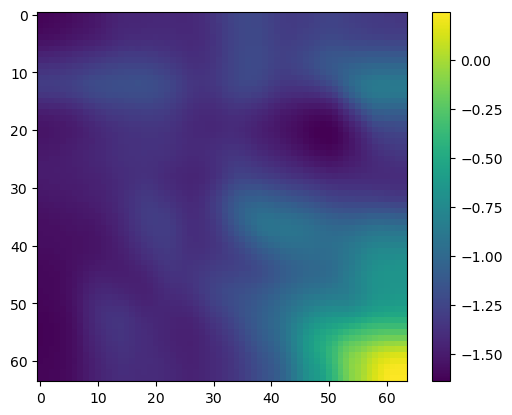

In [7]:
plt.imshow(train_mse_mean_fields[0])
plt.colorbar()

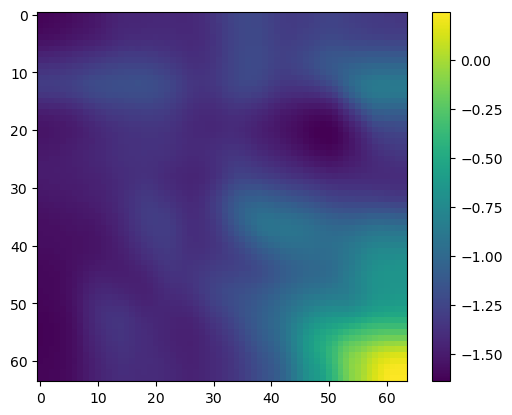

In [8]:
plt.imshow(train_mse_mean_fields[0])
plt.colorbar()

In [9]:
train_mse_mean_fields.shape

(642, 64, 64)

In [10]:
## Test fit results

In [11]:
# ------------------------------
# Load inputs
# ------------------------------
# error_fields = np.load("../stage_1/mse_5l_i123_c32s_padR_schLrG0p95_reg0_TrainErrFields.npy")
s_train = np.load("../stage_2/output/parCov_fitting_fourier_allImages_mseStart_globalPrior_anal_empPriorStdOn0p5_param_fits.npy")
s_test_true = np.load("./output/stage_2c_kappa0p5_param_fits.npy")


In [12]:
s_train.shape

(642, 1089)

In [13]:
s_test_true.shape

(214, 1089)

In [14]:
s_train_grid = s_train.reshape((-1, 33, 33))

In [15]:
s_train_grid[20].shape

(33, 33)

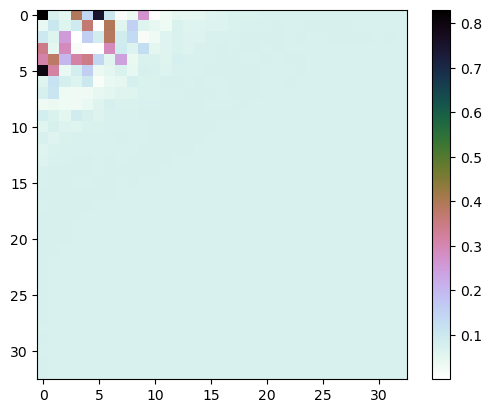

In [16]:
_idx = 0
plt.imshow(s_train_grid[_idx], cmap='cubehelix_r',)
plt.colorbar()
# plt.imshow(s_test_true[_idx])
# plt.colorbar()

In [17]:
s_test_true.shape

(214, 1089)

In [18]:
s_true = s_train              # (642,1089)
s_pred = np.load("train_predicted_s.npy")   # (642,1089)
s_test = np.load("test_predicted_s.npy")   # (214,1089)


In [19]:
s_test.shape

(214, 1089)

In [20]:
# ============================================================
# Build Low-k Mask
# ============================================================
def build_lowk_mask(k_max=10.0):
    """
    Construct a mask for |k| <= k_max over the 33x33 half-plane (kx,ky = 0..32).
    Returns:
        lowk_idx  : array of flattened indices into (33*33=1089)
        mask_flat : boolean mask (1089,)
    """
    N = 64
    kx = np.arange(0, N//2 + 1)  # 0..32
    ky = np.arange(0, N//2 + 1)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    R = np.sqrt(KX**2 + KY**2)

    mask = (R <= k_max)          # (33,33)
    mask_flat = mask.reshape(-1) # (1089,)
    lowk_idx = np.where(mask_flat)[0]

    print(f"Low-k modes: {len(lowk_idx)} of 1089")
    return lowk_idx, mask_flat

In [21]:
lowk_idx, mask_flat = build_lowk_mask(k_max=10)


Low-k modes: 90 of 1089


In [22]:
def to_grid(v):
    return v.reshape(33, 33)


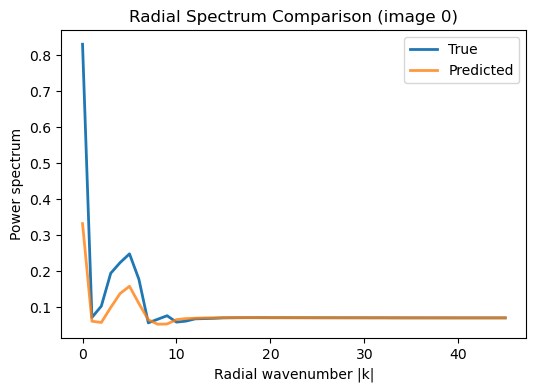

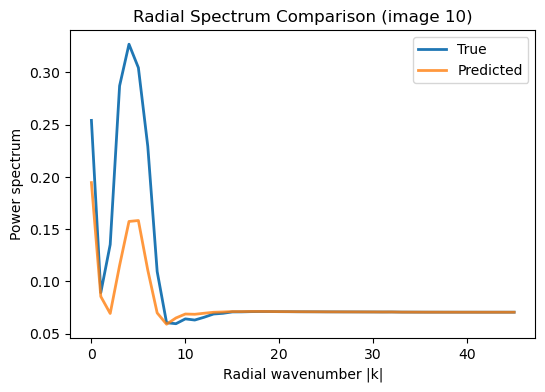

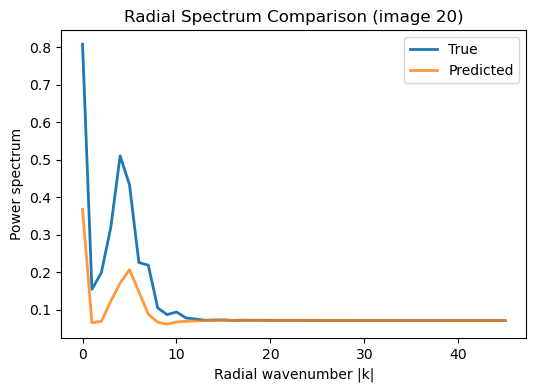

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# compute radial bins
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = (KX**2 + KY**2)**0.5
R_int = R.astype(int)   # integer radii from 0..45 approx

def radial_profile(spec_33x33):
    prof = []
    for r in range(R_int.max()+1):
        prof.append(spec_33x33[R_int == r].mean())
    return np.array(prof)

# visualize for a few images
for idx in [0, 10, 20]:
    plt.figure(figsize=(6,4))
    true_grid = to_grid(s_true[idx])
    pred_grid = to_grid(s_pred[idx])
    
    rt = radial_profile(true_grid)
    rp = radial_profile(pred_grid)
    
    plt.plot(rt, label="True", lw=2)
    plt.plot(rp, label="Predicted", lw=2, alpha=0.8)
    # plt.yscale("log")
    plt.xlabel("Radial wavenumber |k|")
    plt.ylabel("Power spectrum")
    plt.title(f"Radial Spectrum Comparison (image {idx})")
    plt.legend()
    plt.show()


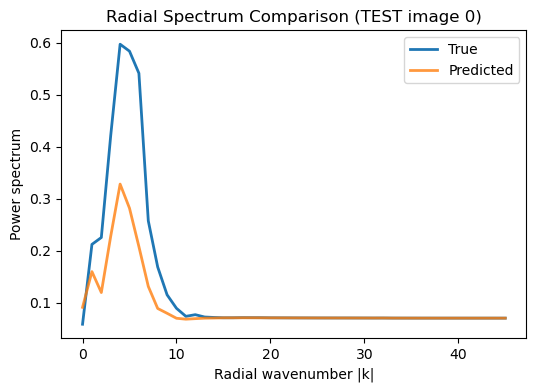

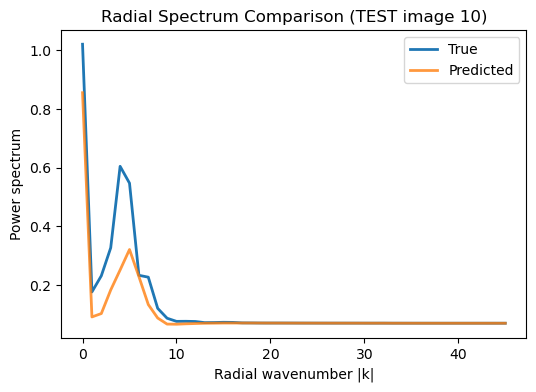

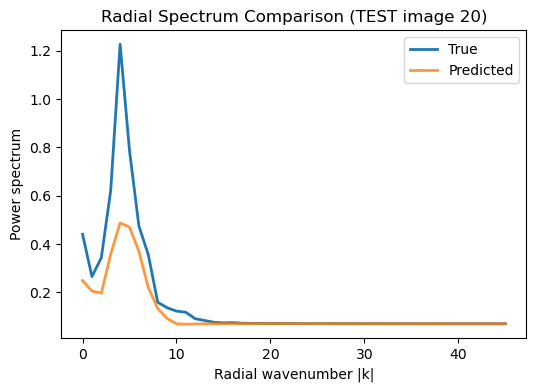

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# visualize for a few images
for idx in [0, 10, 20]:
    plt.figure(figsize=(6,4))
    true_grid = to_grid(s_test_true[idx])
    pred_grid = to_grid(s_test[idx])
    
    rt = radial_profile(true_grid)
    rp = radial_profile(pred_grid)
    
    plt.plot(rt, label="True", lw=2)
    plt.plot(rp, label="Predicted", lw=2, alpha=0.8)
    # plt.yscale("log")
    plt.xlabel("Radial wavenumber |k|")
    plt.ylabel("Power spectrum")
    plt.title(f"Radial Spectrum Comparison (TEST image {idx})")
    plt.legend()
    plt.show()


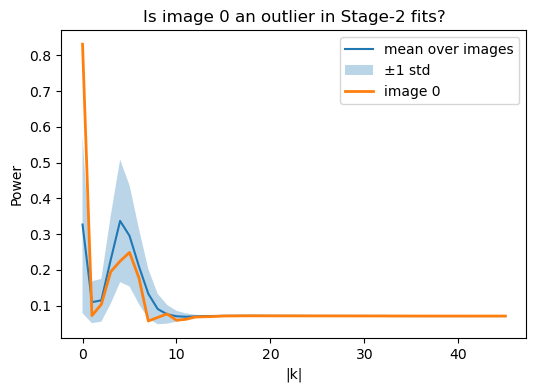

In [25]:
def radial_profile(spec_33x33, R_int):
    vals = []
    for r in range(R_int.max()+1):
        vals.append(spec_33x33[R_int == r].mean())
    return np.array(vals)

# build R_int once
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R_int = np.sqrt(KX**2 + KY**2).astype(int)

rt_all = []
for i in range(s_train.shape[0]):
    rt_all.append(radial_profile(s_train[i].reshape(33,33), R_int))
rt_all = np.stack(rt_all, axis=0)  # (N, n_r)

rt_mean = rt_all.mean(axis=0)
rt_std  = rt_all.std(axis=0)
rt_0    = radial_profile(s_train[0].reshape(33,33), R_int)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(rt_mean, label="mean over images")
plt.fill_between(
    np.arange(len(rt_mean)),
    rt_mean - rt_std,
    rt_mean + rt_std,
    alpha=0.3,
    label="±1 std"
)
plt.plot(rt_0, label="image 0", lw=2)
# plt.yscale("log")
plt.xlabel("|k|")
plt.ylabel("Power")
plt.legend()
plt.title("Is image 0 an outlier in Stage-2 fits?")
plt.show()


Plot train and test goodness of fit

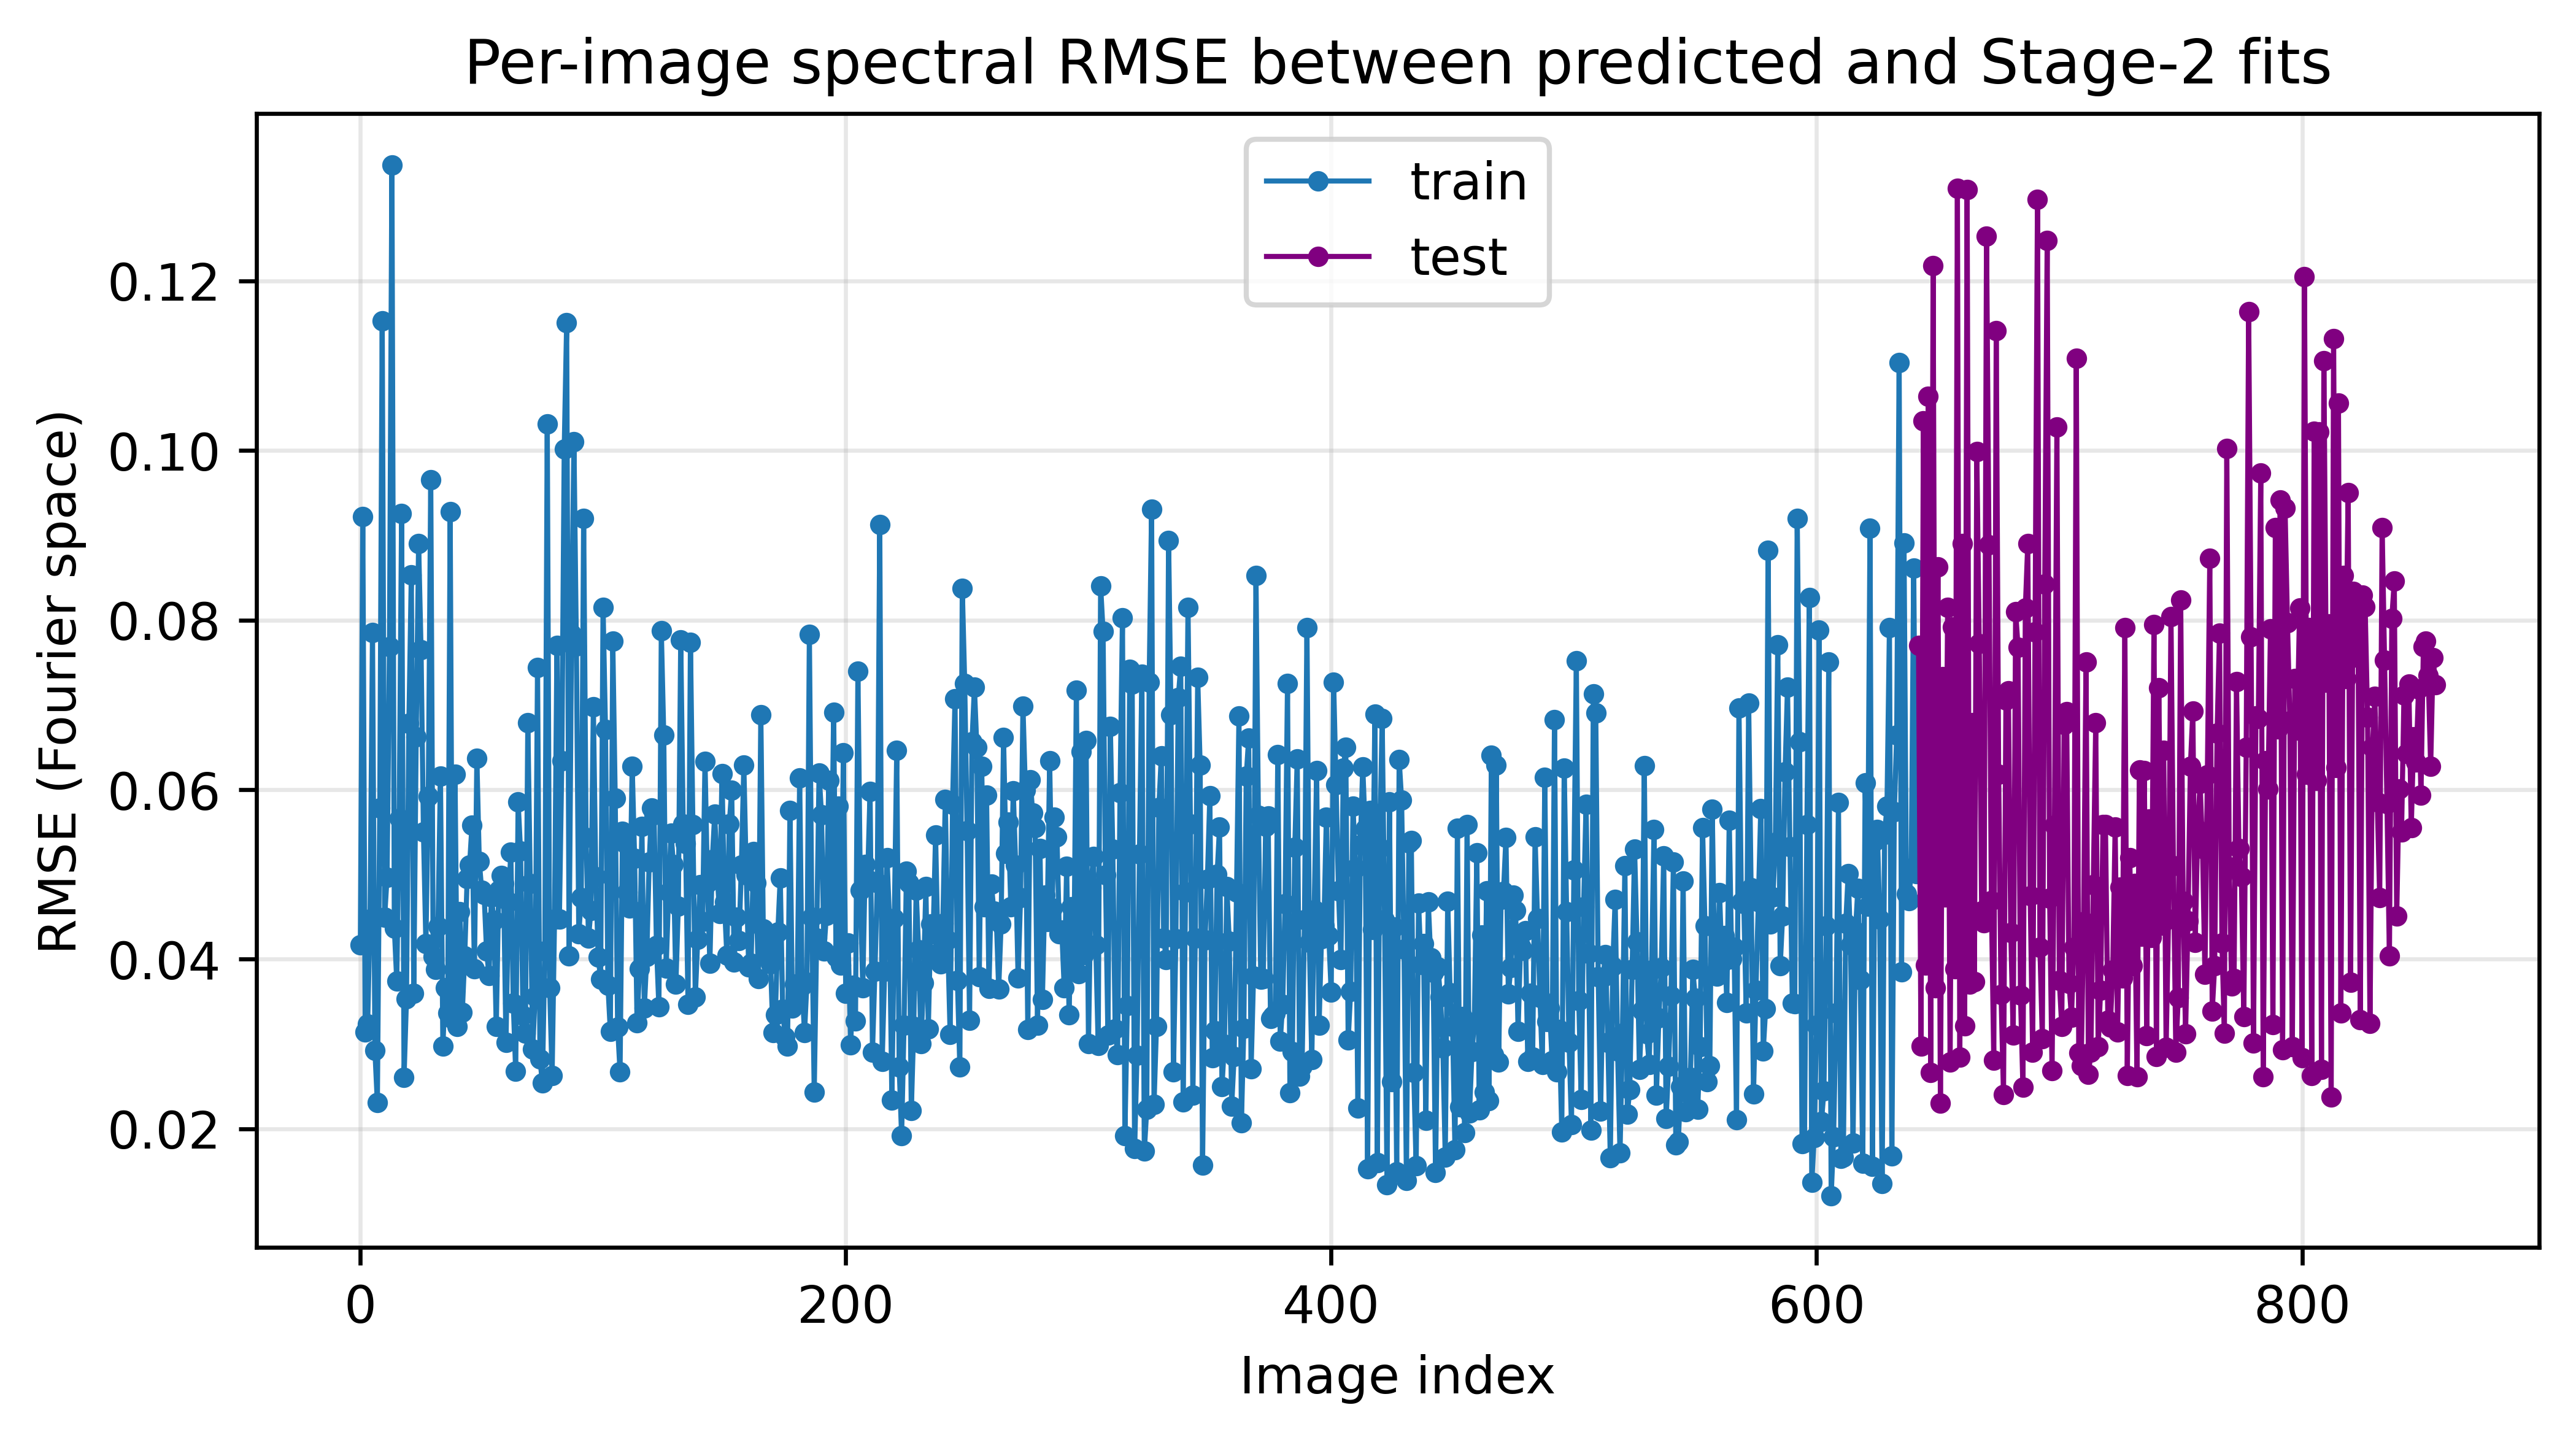

In [26]:
# assume shapes (N,1089)
s_true = s_train
s_pred = np.load("train_predicted_s.npy")

rmse_train = np.sqrt(np.mean((s_pred - s_true)**2, axis=1))  # shape (N,)

plt.figure(figsize=(8,4), dpi=600)
plt.plot(rmse_train, marker='o', ms=3, lw=1, label='train')
plt.xlabel("Image index")
plt.ylabel("RMSE (Fourier space)")
plt.title("Per-image spectral RMSE between predicted and Stage-2 fits")
plt.grid(alpha=0.3)

# # highlight the worst one
# bad = np.argmax(rmse_train)
# plt.scatter([bad], [rmse_train[bad]], color='red', s=80, label=f"worst: {bad}")


## Test
rmse_test = np.sqrt(np.mean((s_test - s_test_true)**2, axis=1))  # shape (N,)

plt.plot(np.arange(len(rmse_test)) + len(rmse_train), rmse_test, marker='o', ms=3, lw=1, label='test', color='purple')
# plt.xlabel("Image index")
# plt.ylabel("RMSE (Fourier space)")
# plt.title("Per-image spectral RMSE between predicted and Stage-2 fits")
plt.grid(alpha=0.3)

# # highlight the worst one
# bad = np.argmax(rmse_test)
# plt.scatter([bad], [rmse_test[bad]], color='red', s=80, label=f"worst: {bad}")


plt.legend()
plt.show()

In [27]:
rmse_test.shape

(214,)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


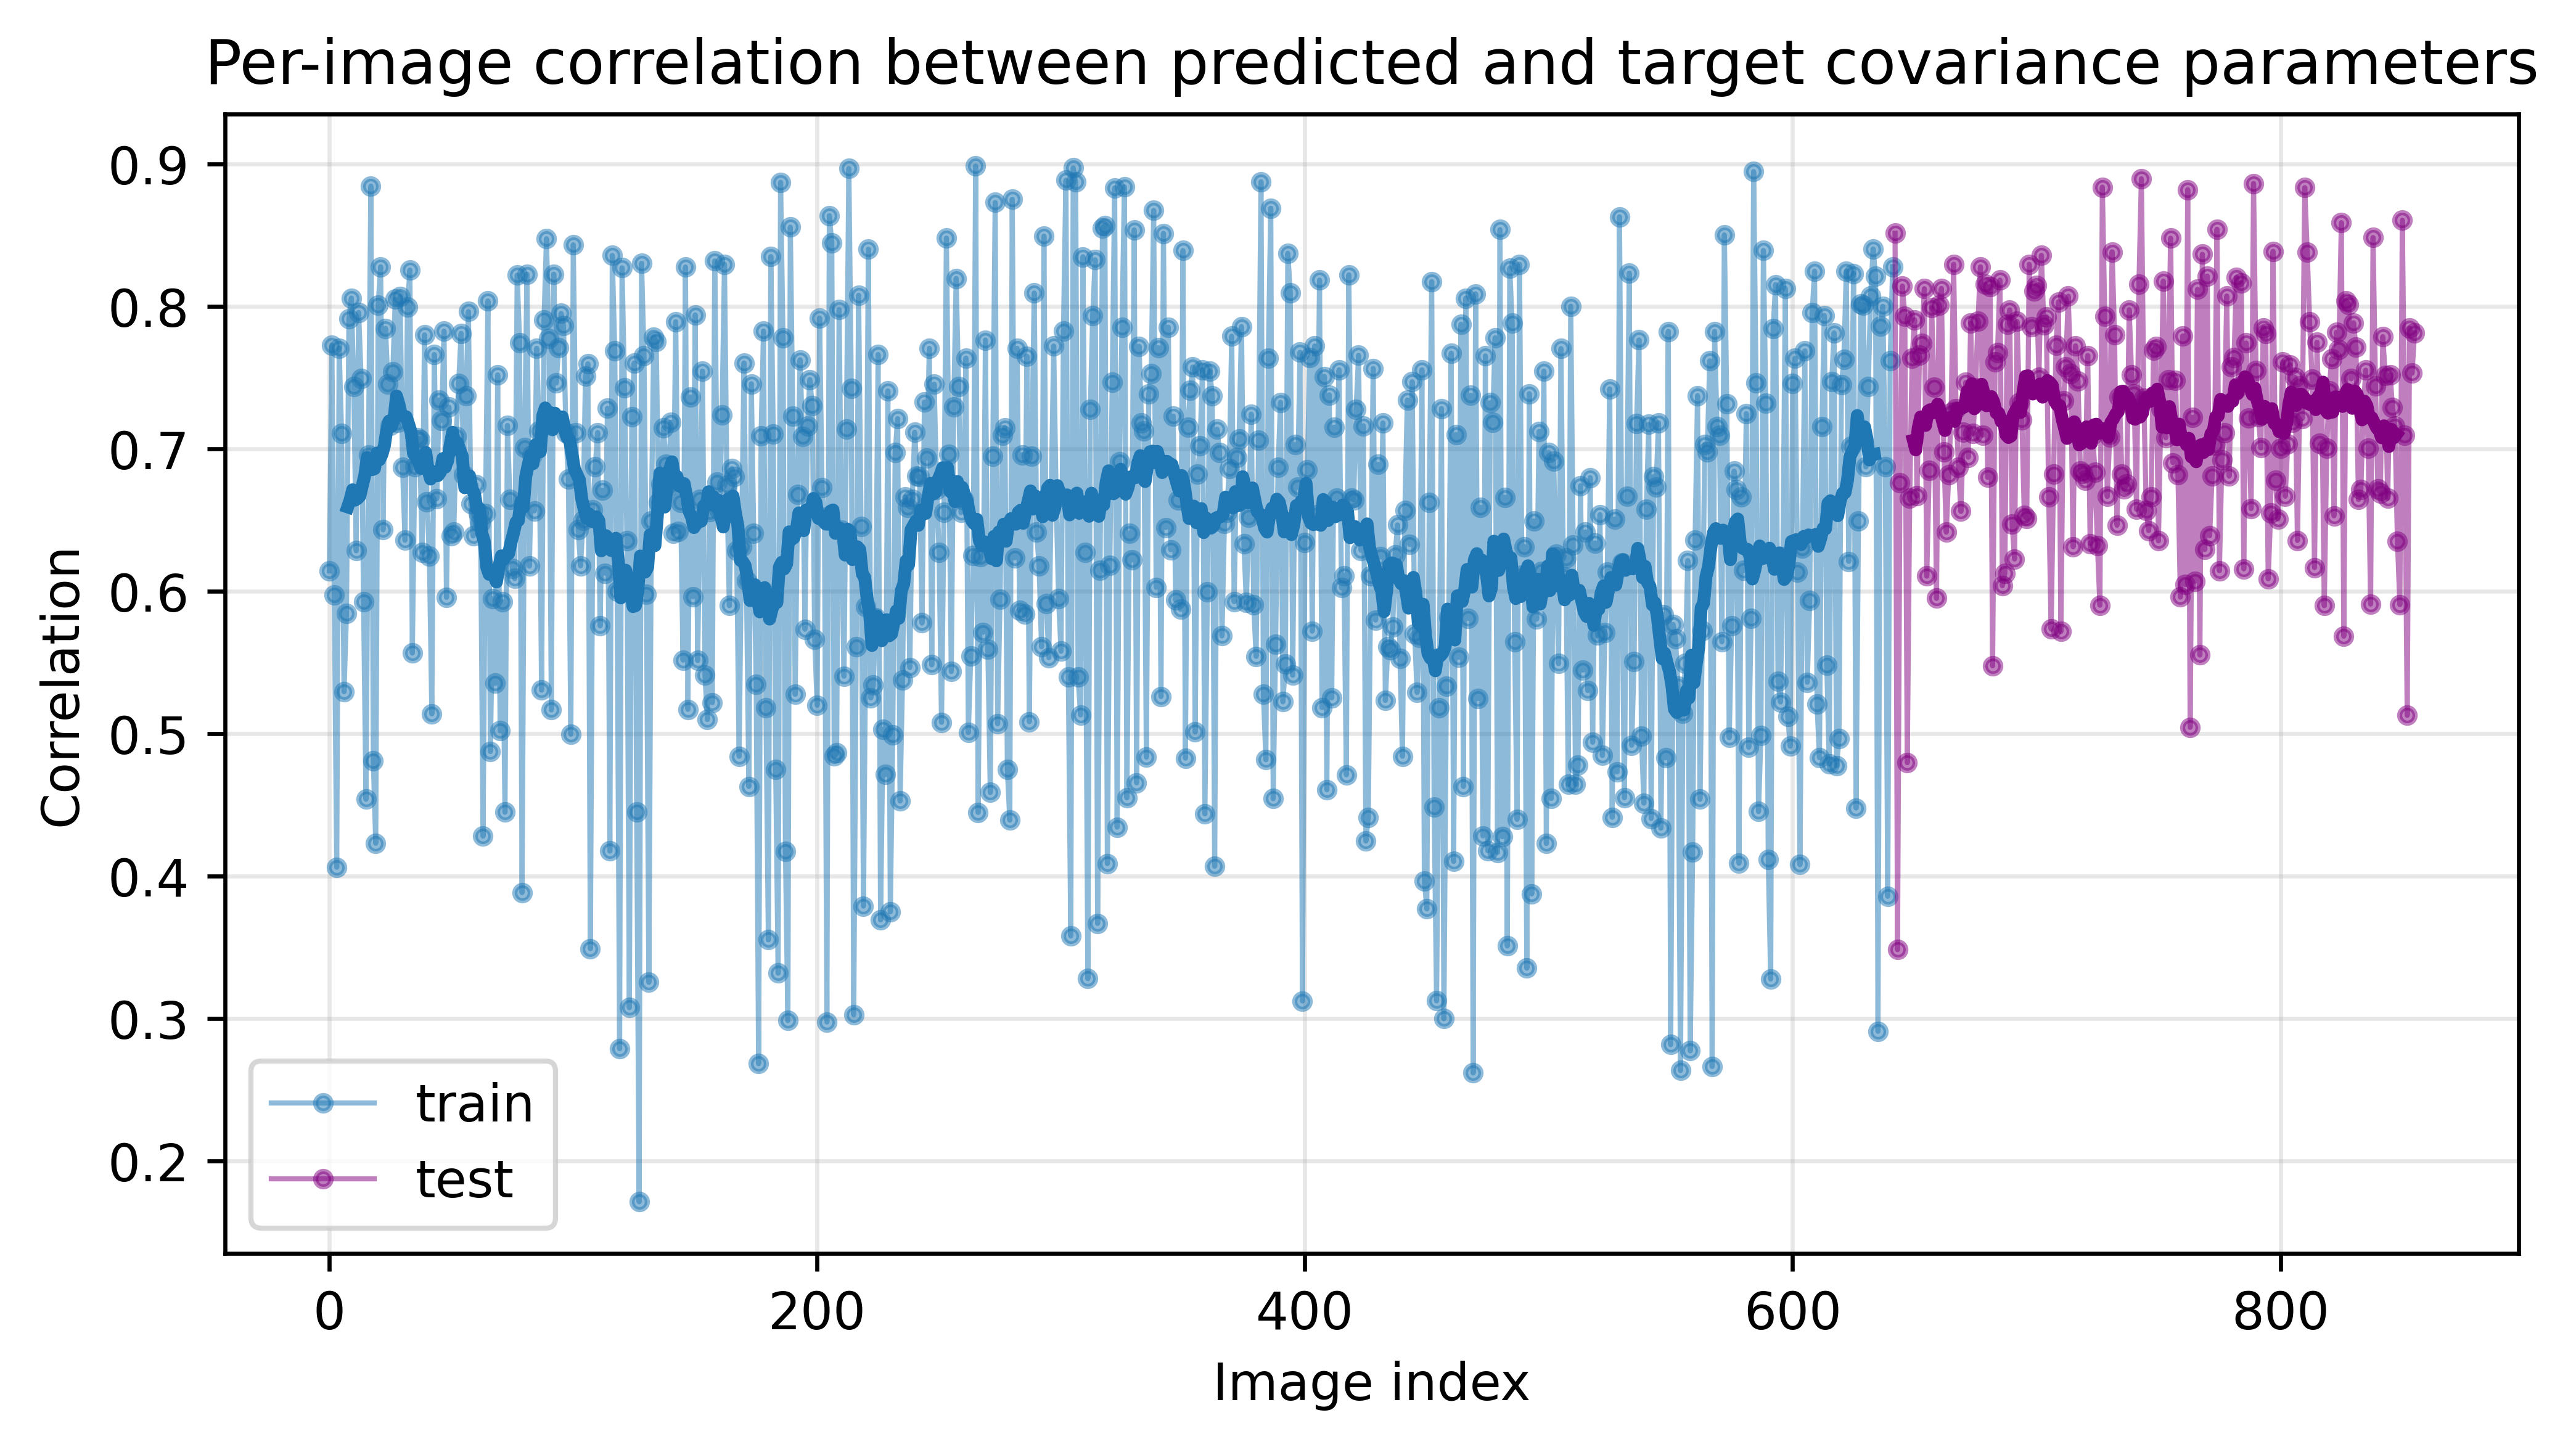

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Utilities
# ======================

def rolling_mean(x, window=8):
    """
    Centered rolling mean using convolution.
    Returns an array of length len(x) - window + 1.
    """
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


# ======================
# Load data
# ======================

# assume shapes (N, 1089)
s_true = s_train
s_pred = np.load("train_predicted_s.npy")

# ======================
# Train correlations
# ======================

train_corr = np.array([
    np.corrcoef(s_true[i], s_pred[i])[0, 1]
    for i in range(len(s_true))
])

# ======================
# Test correlations
# ======================

test_corr = np.array([
    np.corrcoef(s_test_true[i], s_test[i])[0, 1]
    for i in range(len(s_test_true))
])

# ======================
# Rolling means
# ======================

window = 16

train_rm = rolling_mean(train_corr, window)
train_x_rm = np.arange(len(train_rm)) + (window - 1) / 2

test_rm = rolling_mean(test_corr, window)
test_x_rm = (
    np.arange(len(test_rm)) + len(train_corr) + (window - 1) / 2
)

# ======================
# Plot
# ======================

plt.figure(figsize=(8, 4), dpi=600)

# Raw correlations
plt.plot(
    train_corr,
    marker='o',
    ms=3,
    lw=1,
    alpha=0.5,
    label='train',
)

plt.plot(
    np.arange(len(test_corr)) + len(train_corr),
    test_corr,
    marker='o',
    ms=3,
    lw=1,
    alpha=0.5,
    color='purple',
    label='test',
)

# Rolling means (emphasized)
plt.plot(
    train_x_rm,
    train_rm,
    lw=2.5,
    color='C0',
    # label='train (rolling mean)',
)

plt.plot(
    test_x_rm,
    test_rm,
    lw=2.5,
    color='purple',
    # label='test (rolling mean)',
)

# Labels & formatting
plt.xlabel("Image index")
plt.ylabel("Correlation")
plt.title("Per-image correlation between predicted and target covariance parameters")
plt.grid(alpha=0.3)
plt.legend()

# Optional: save for appendix
# plt.savefig("per_image_correlation_with_rolling_mean.pdf", dpi=600, bbox_inches="tight")

plt.show()


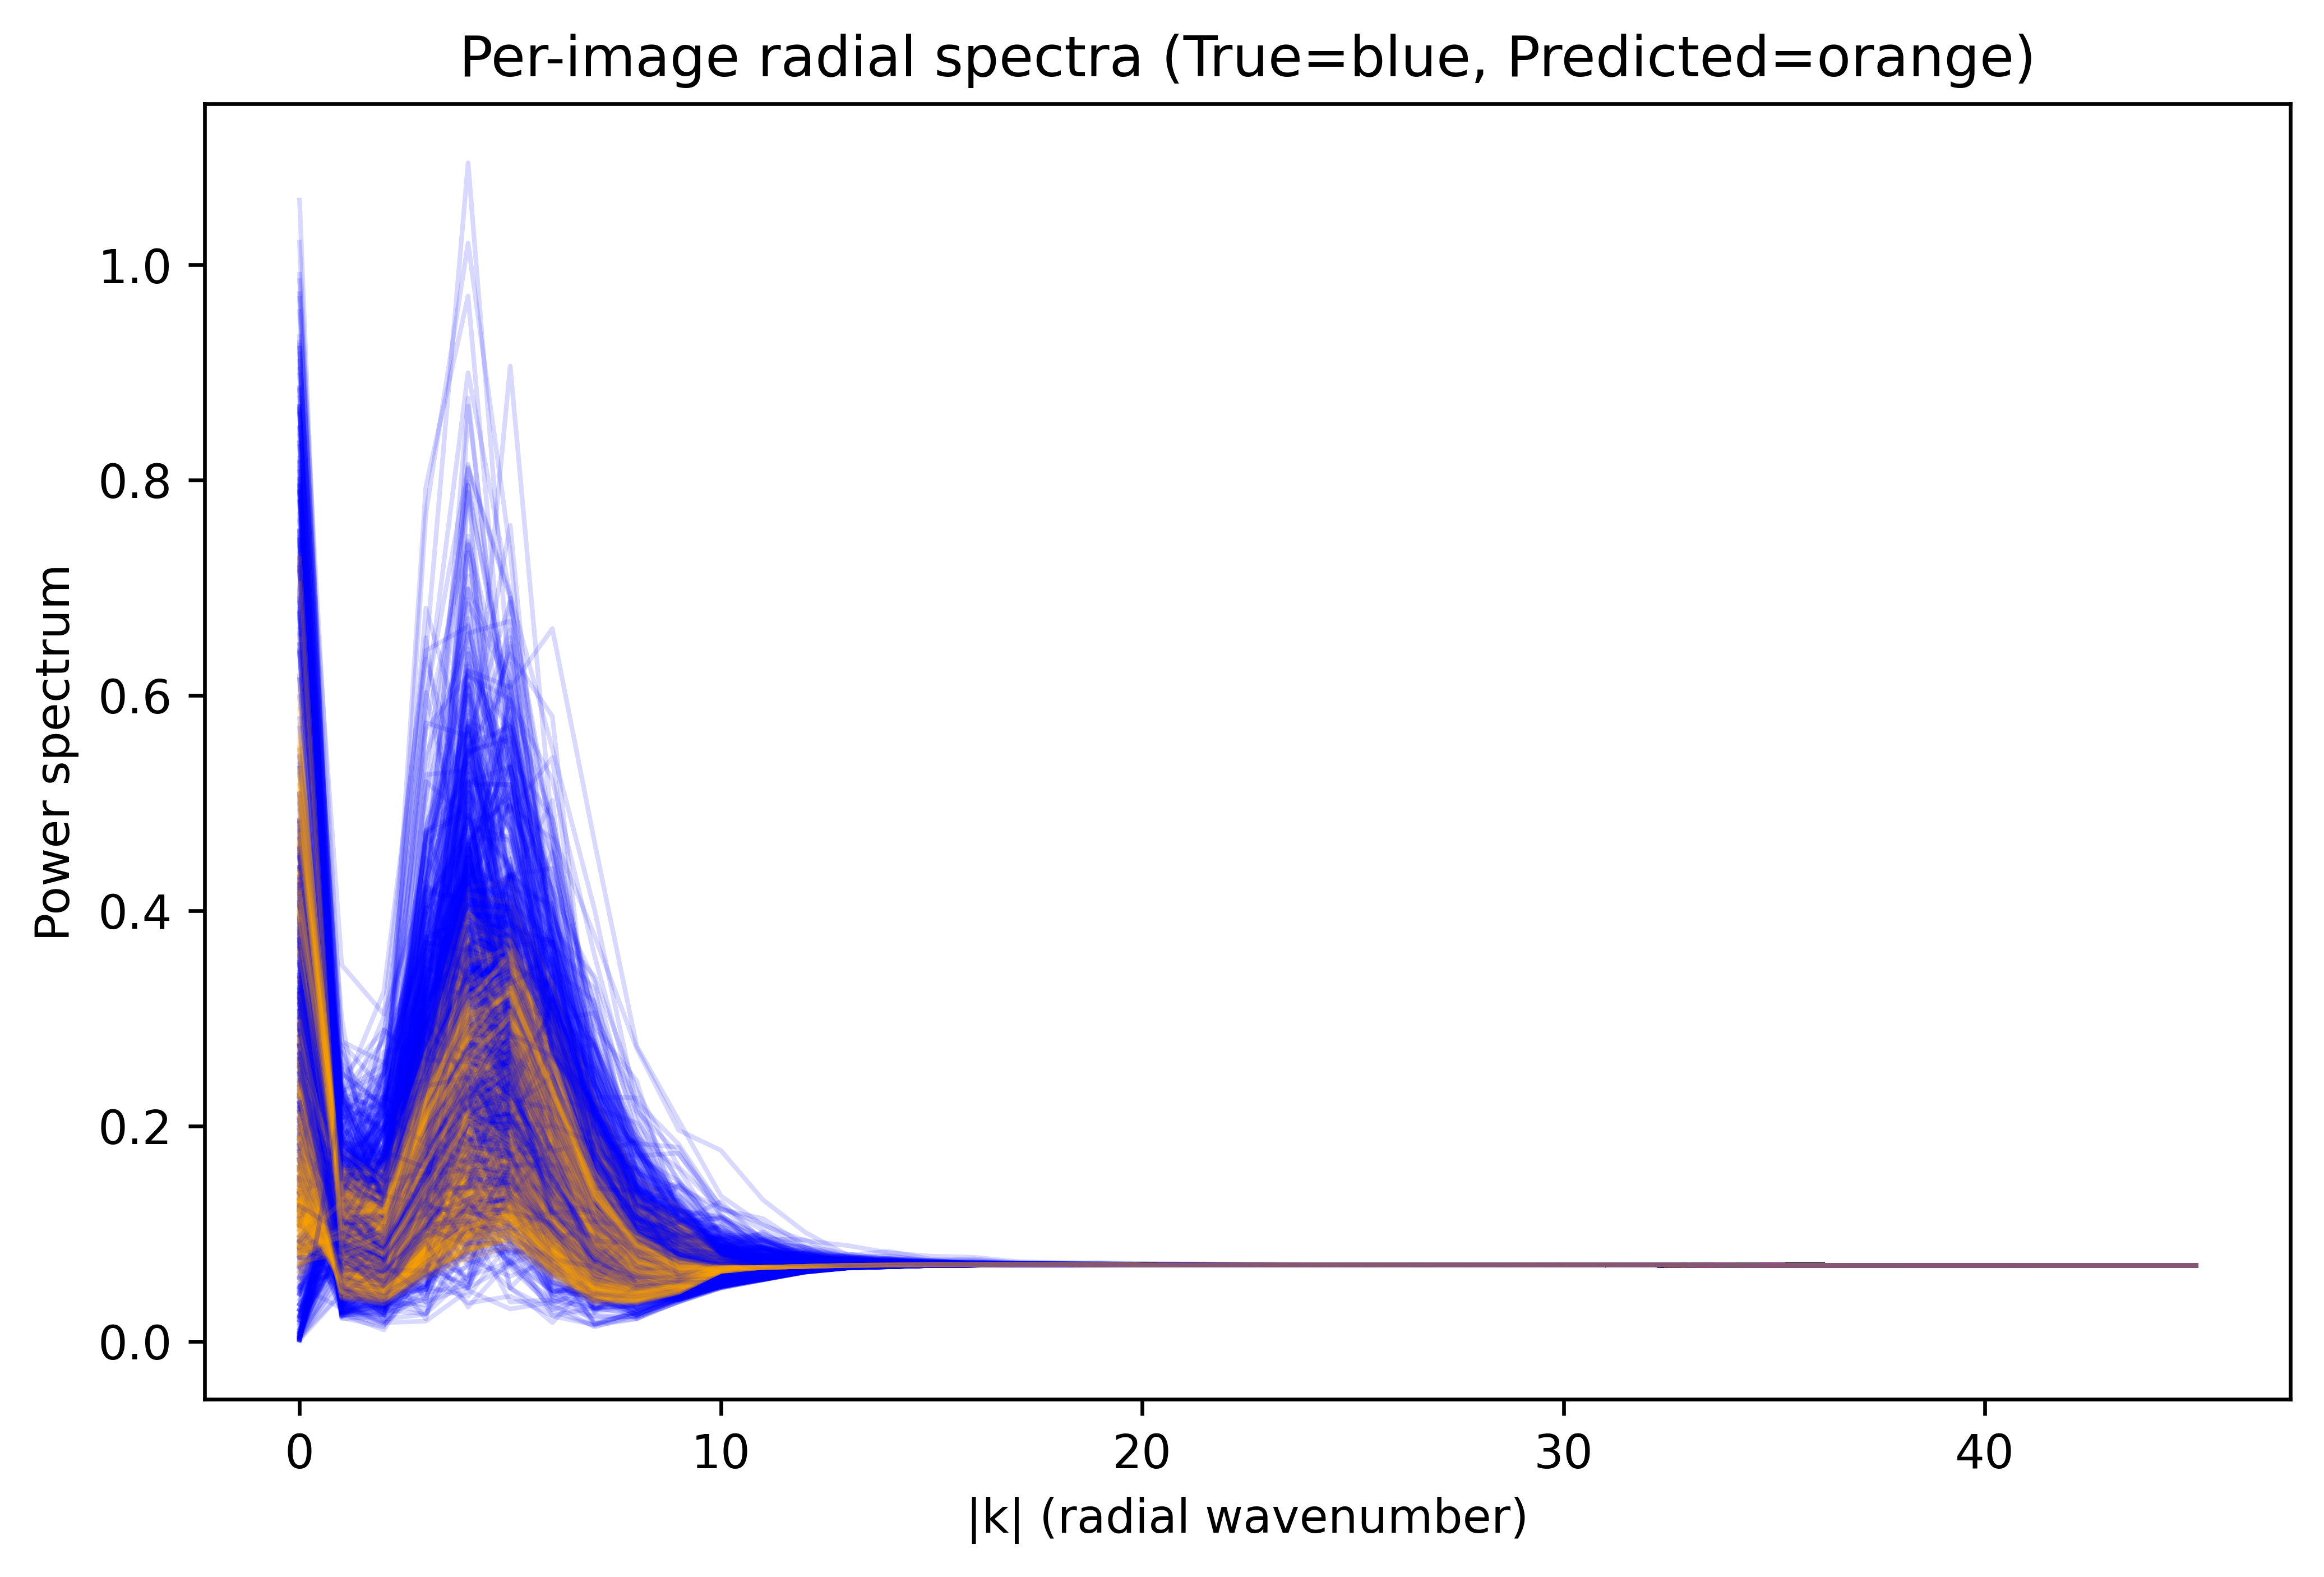

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# s_true, s_pred are (N,1089)

# --- build radial bins ---
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)     # 0..~45

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33,33)
    prof = []
    for r in range(R.max()+1):
        prof.append(grid[R == r].mean())
    return np.array(prof)

# --- compute all profiles ---
true_profiles = np.array([radial_profile(s_true[i]) for i in range(len(s_true))])
pred_profiles = np.array([radial_profile(s_pred[i]) for i in range(len(s_pred))])

# --- simple plot per image ---
plt.figure(figsize=(8,5), dpi=600)

for i in range(len(true_profiles)):
    plt.plot(true_profiles[i], color='blue', alpha=0.15, lw=1)
    plt.plot(pred_profiles[i], color='orange', alpha=0.15, lw=1)

# plt.yscale("log")
plt.xlabel("|k| (radial wavenumber)")
plt.ylabel("Power spectrum")
plt.title("Per-image radial spectra (True=blue, Predicted=orange)")
plt.show()


(-0.1, 10.0)

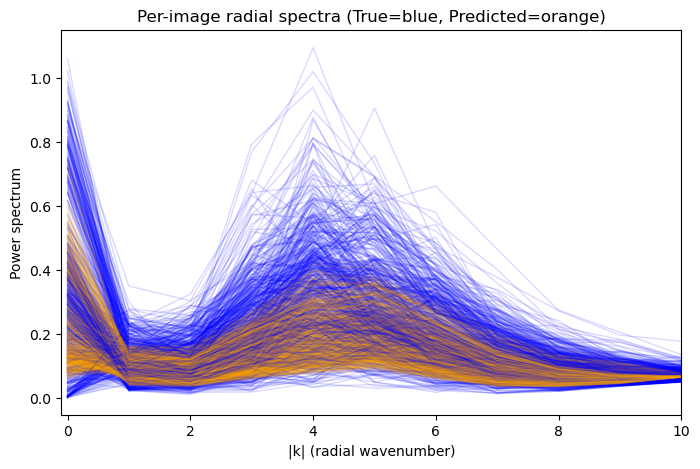

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# s_true, s_pred are (N,1089)

# --- build radial bins ---
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)     # 0..~45

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33,33)
    prof = []
    for r in range(R.max()+1):
        prof.append(grid[R == r].mean())
    return np.array(prof)

# --- compute all profiles ---
true_profiles = np.array([radial_profile(s_true[i]) for i in range(len(s_true))])
pred_profiles = np.array([radial_profile(s_pred[i]) for i in range(len(s_pred))])

# --- simple plot per image ---
plt.figure(figsize=(8,5))

for i in range(len(true_profiles)):
    plt.plot(true_profiles[i], color='blue', alpha=0.15, lw=1)
    plt.plot(pred_profiles[i], color='orange', alpha=0.15, lw=1)

# plt.yscale("log")
plt.xlabel("|k| (radial wavenumber)")
plt.ylabel("Power spectrum")
plt.title("Per-image radial spectra (True=blue, Predicted=orange)")
# plt.show()
plt.xlim(-.1, 10)


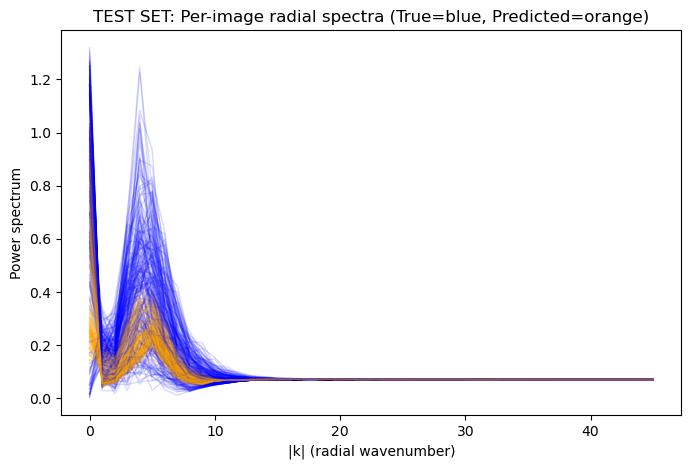

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# s_test_true, s_test are (N,1089)

# --- build radial bins ---
kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)     # 0..~45

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33,33)
    prof = []
    for r in range(R.max()+1):
        prof.append(grid[R == r].mean())
    return np.array(prof)

# --- compute all profiles ---
true_profiles = np.array([radial_profile(s_test_true[i]) for i in range(len(s_test_true))])
pred_profiles = np.array([radial_profile(s_test[i]) for i in range(len(s_test))])

# --- simple plot per image ---
plt.figure(figsize=(8,5))

for i in range(len(true_profiles)):
    plt.plot(true_profiles[i], color='blue', alpha=0.15, lw=1)
    plt.plot(pred_profiles[i], color='orange', alpha=0.15, lw=1)

# plt.yscale("log")
plt.xlabel("|k| (radial wavenumber)")
plt.ylabel("Power spectrum")
plt.title("TEST SET: Per-image radial spectra (True=blue, Predicted=orange)")
plt.show()


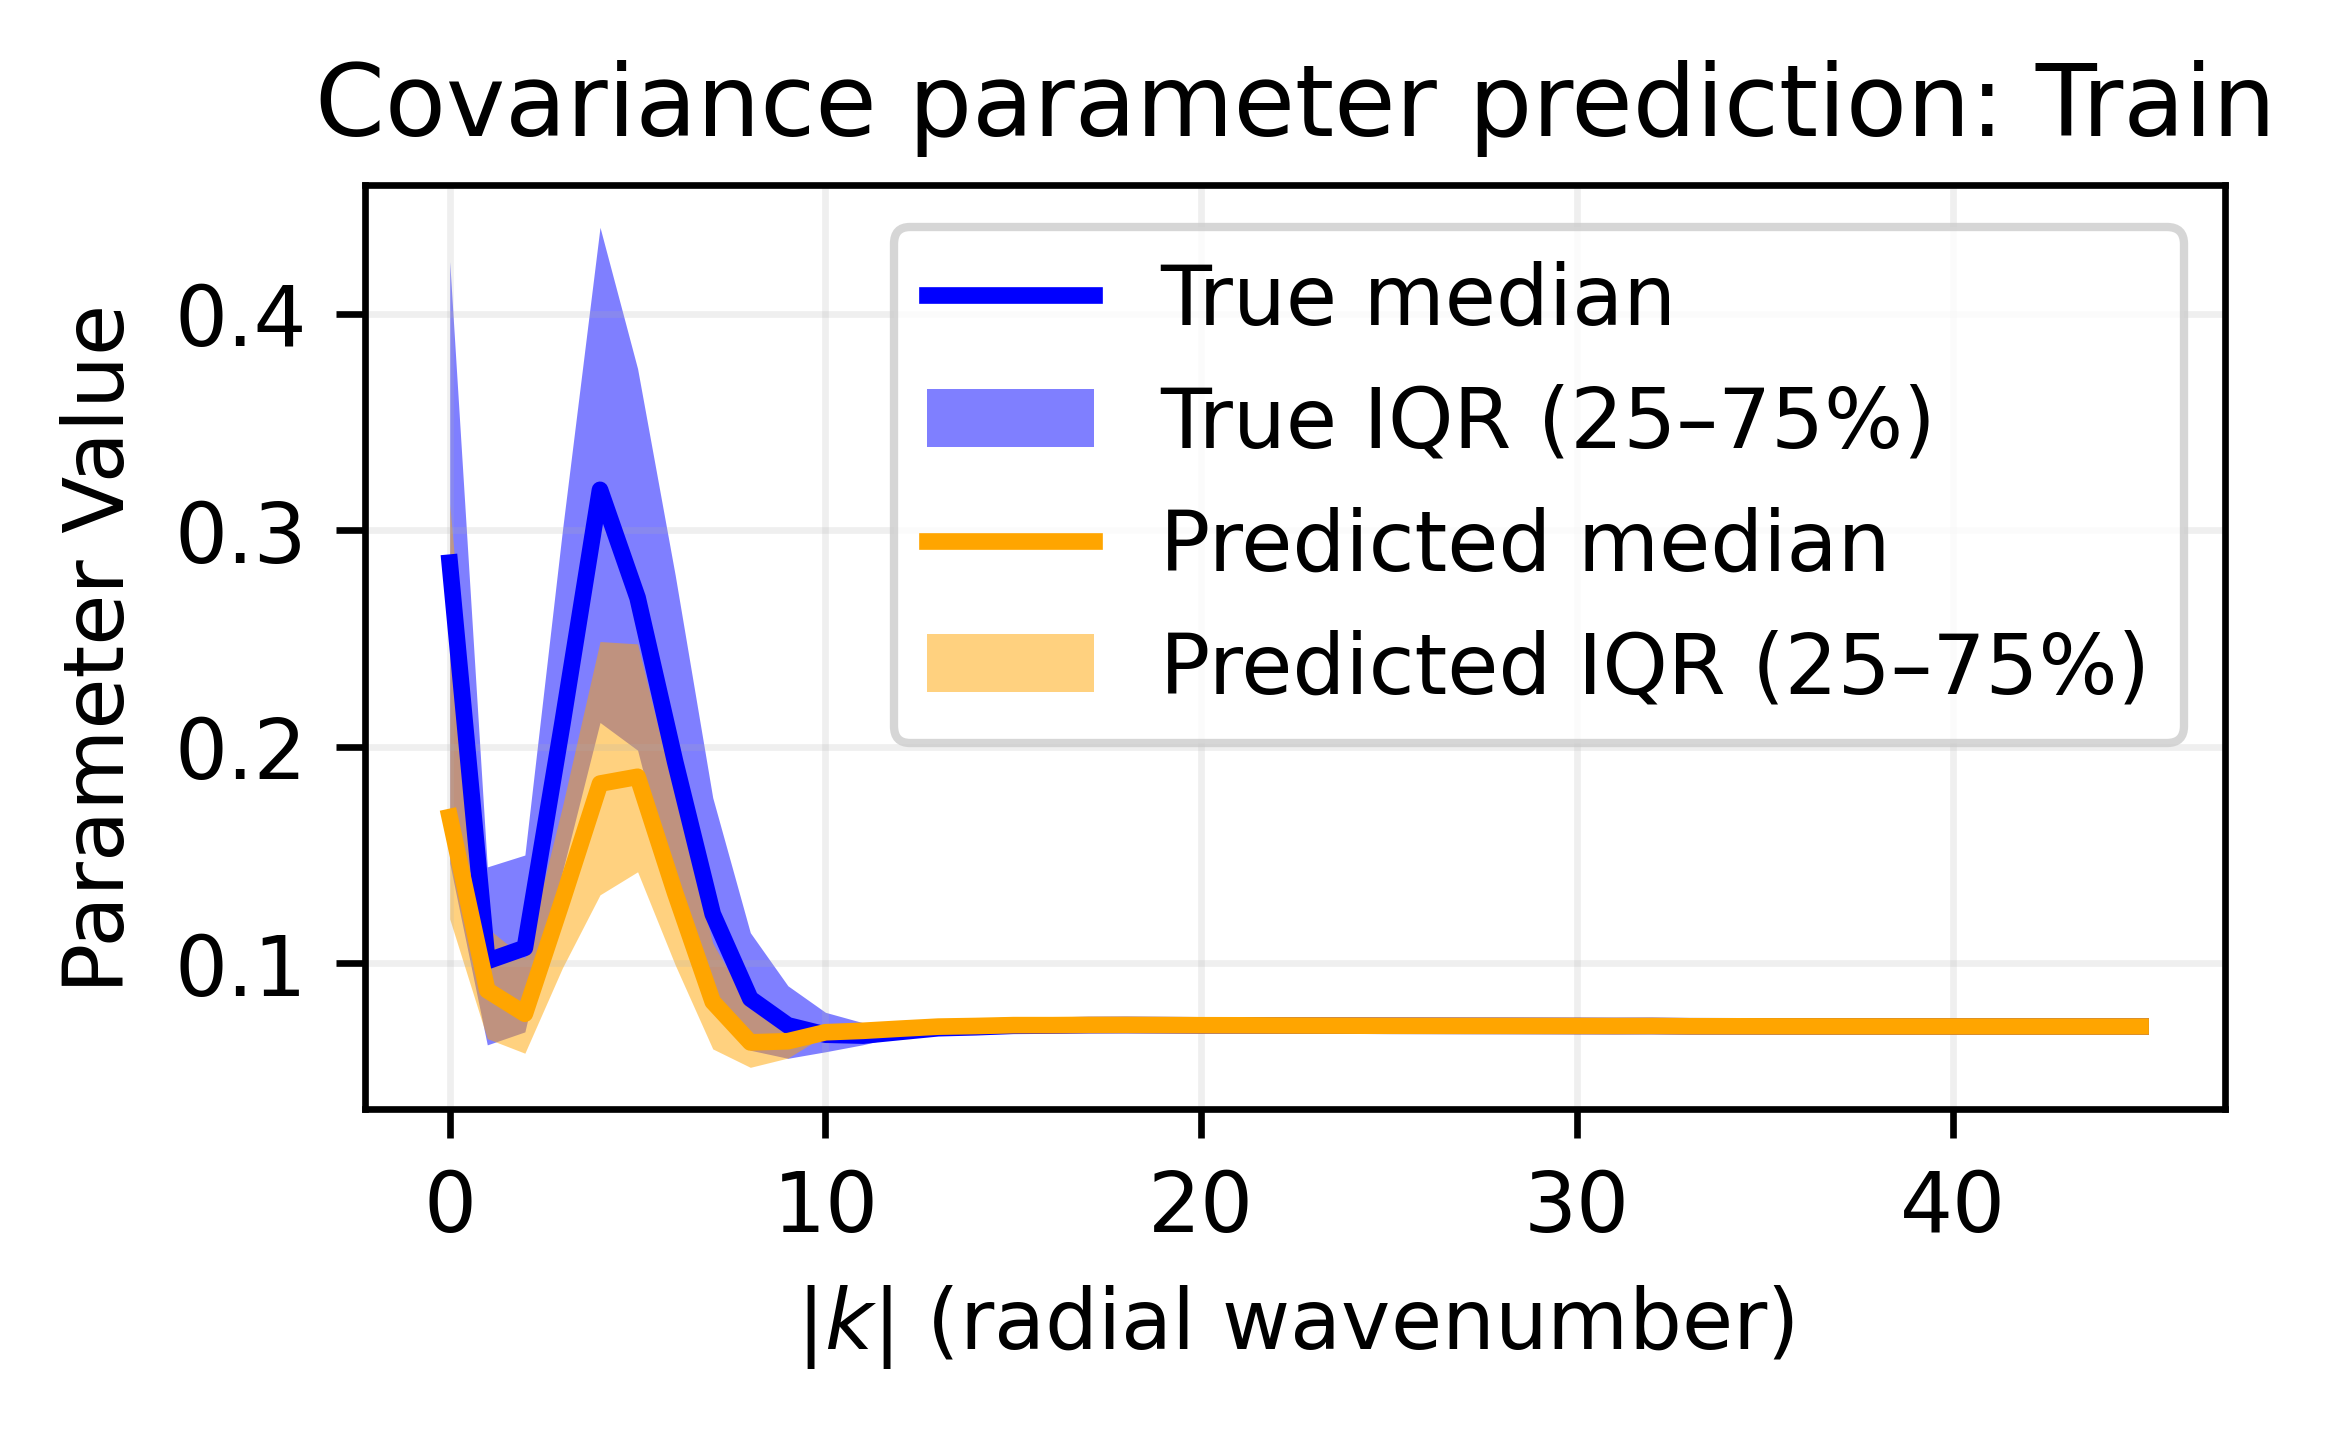

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Build radial bins
# ======================

kx = np.arange(33)
ky = np.arange(33)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
R = np.sqrt(KX**2 + KY**2).astype(int)

def radial_profile(spec_1089):
    grid = spec_1089.reshape(33, 33)
    vals = []
    for r in range(R.max() + 1):
        vals.append(grid[R == r].mean())
    return np.array(vals)

# ======================
# Compute radial profiles
# ======================

true_profiles = np.array([
    radial_profile(s_true[i]) for i in range(len(s_true))
])

pred_profiles = np.array([
    radial_profile(s_pred[i]) for i in range(len(s_pred))
])

# ======================
# Quantiles
# ======================

# Choose quantiles
q_lo, q_med, q_hi = 0.25, 0.50, 0.75

true_q_lo  = np.quantile(true_profiles, q_lo, axis=0)
true_q_med = np.quantile(true_profiles, q_med, axis=0)
true_q_hi  = np.quantile(true_profiles, q_hi, axis=0)

pred_q_lo  = np.quantile(pred_profiles, q_lo, axis=0)
pred_q_med = np.quantile(pred_profiles, q_med, axis=0)
pred_q_hi  = np.quantile(pred_profiles, q_hi, axis=0)

r = np.arange(len(true_q_med))

# ======================
# Plot
# ======================

plt.figure(figsize=(4, 2), dpi=600)

# --- True ---
plt.plot(
    r,
    true_q_med,
    color="blue",
    lw=2,
    label="True median",
)
plt.fill_between(
    r,
    true_q_lo,
    true_q_hi,
    color="blue",
    alpha=0.5,
    lw=0,
    label="True IQR (25–75%)",
)

# --- Predicted ---
plt.plot(
    r,
    pred_q_med,
    color="orange",
    lw=2,
    label="Predicted median",
)
plt.fill_between(
    r,
    pred_q_lo,
    pred_q_hi,
    color="orange",
    alpha=0.5,
    lw=0,
    label="Predicted IQR (25–75%)",
)

# Formatting
plt.xlabel(r"$|k|$ (radial wavenumber)")
plt.ylabel("Parameter Value")
plt.title("Covariance parameter prediction: Train")
plt.grid(alpha=0.2)
plt.legend()

# Optional for spectra
# plt.yscale("log")

# Optional: save for appendix
# plt.savefig("radial_spectrum_quantiles.pdf", bbox_inches="tight")

plt.show()


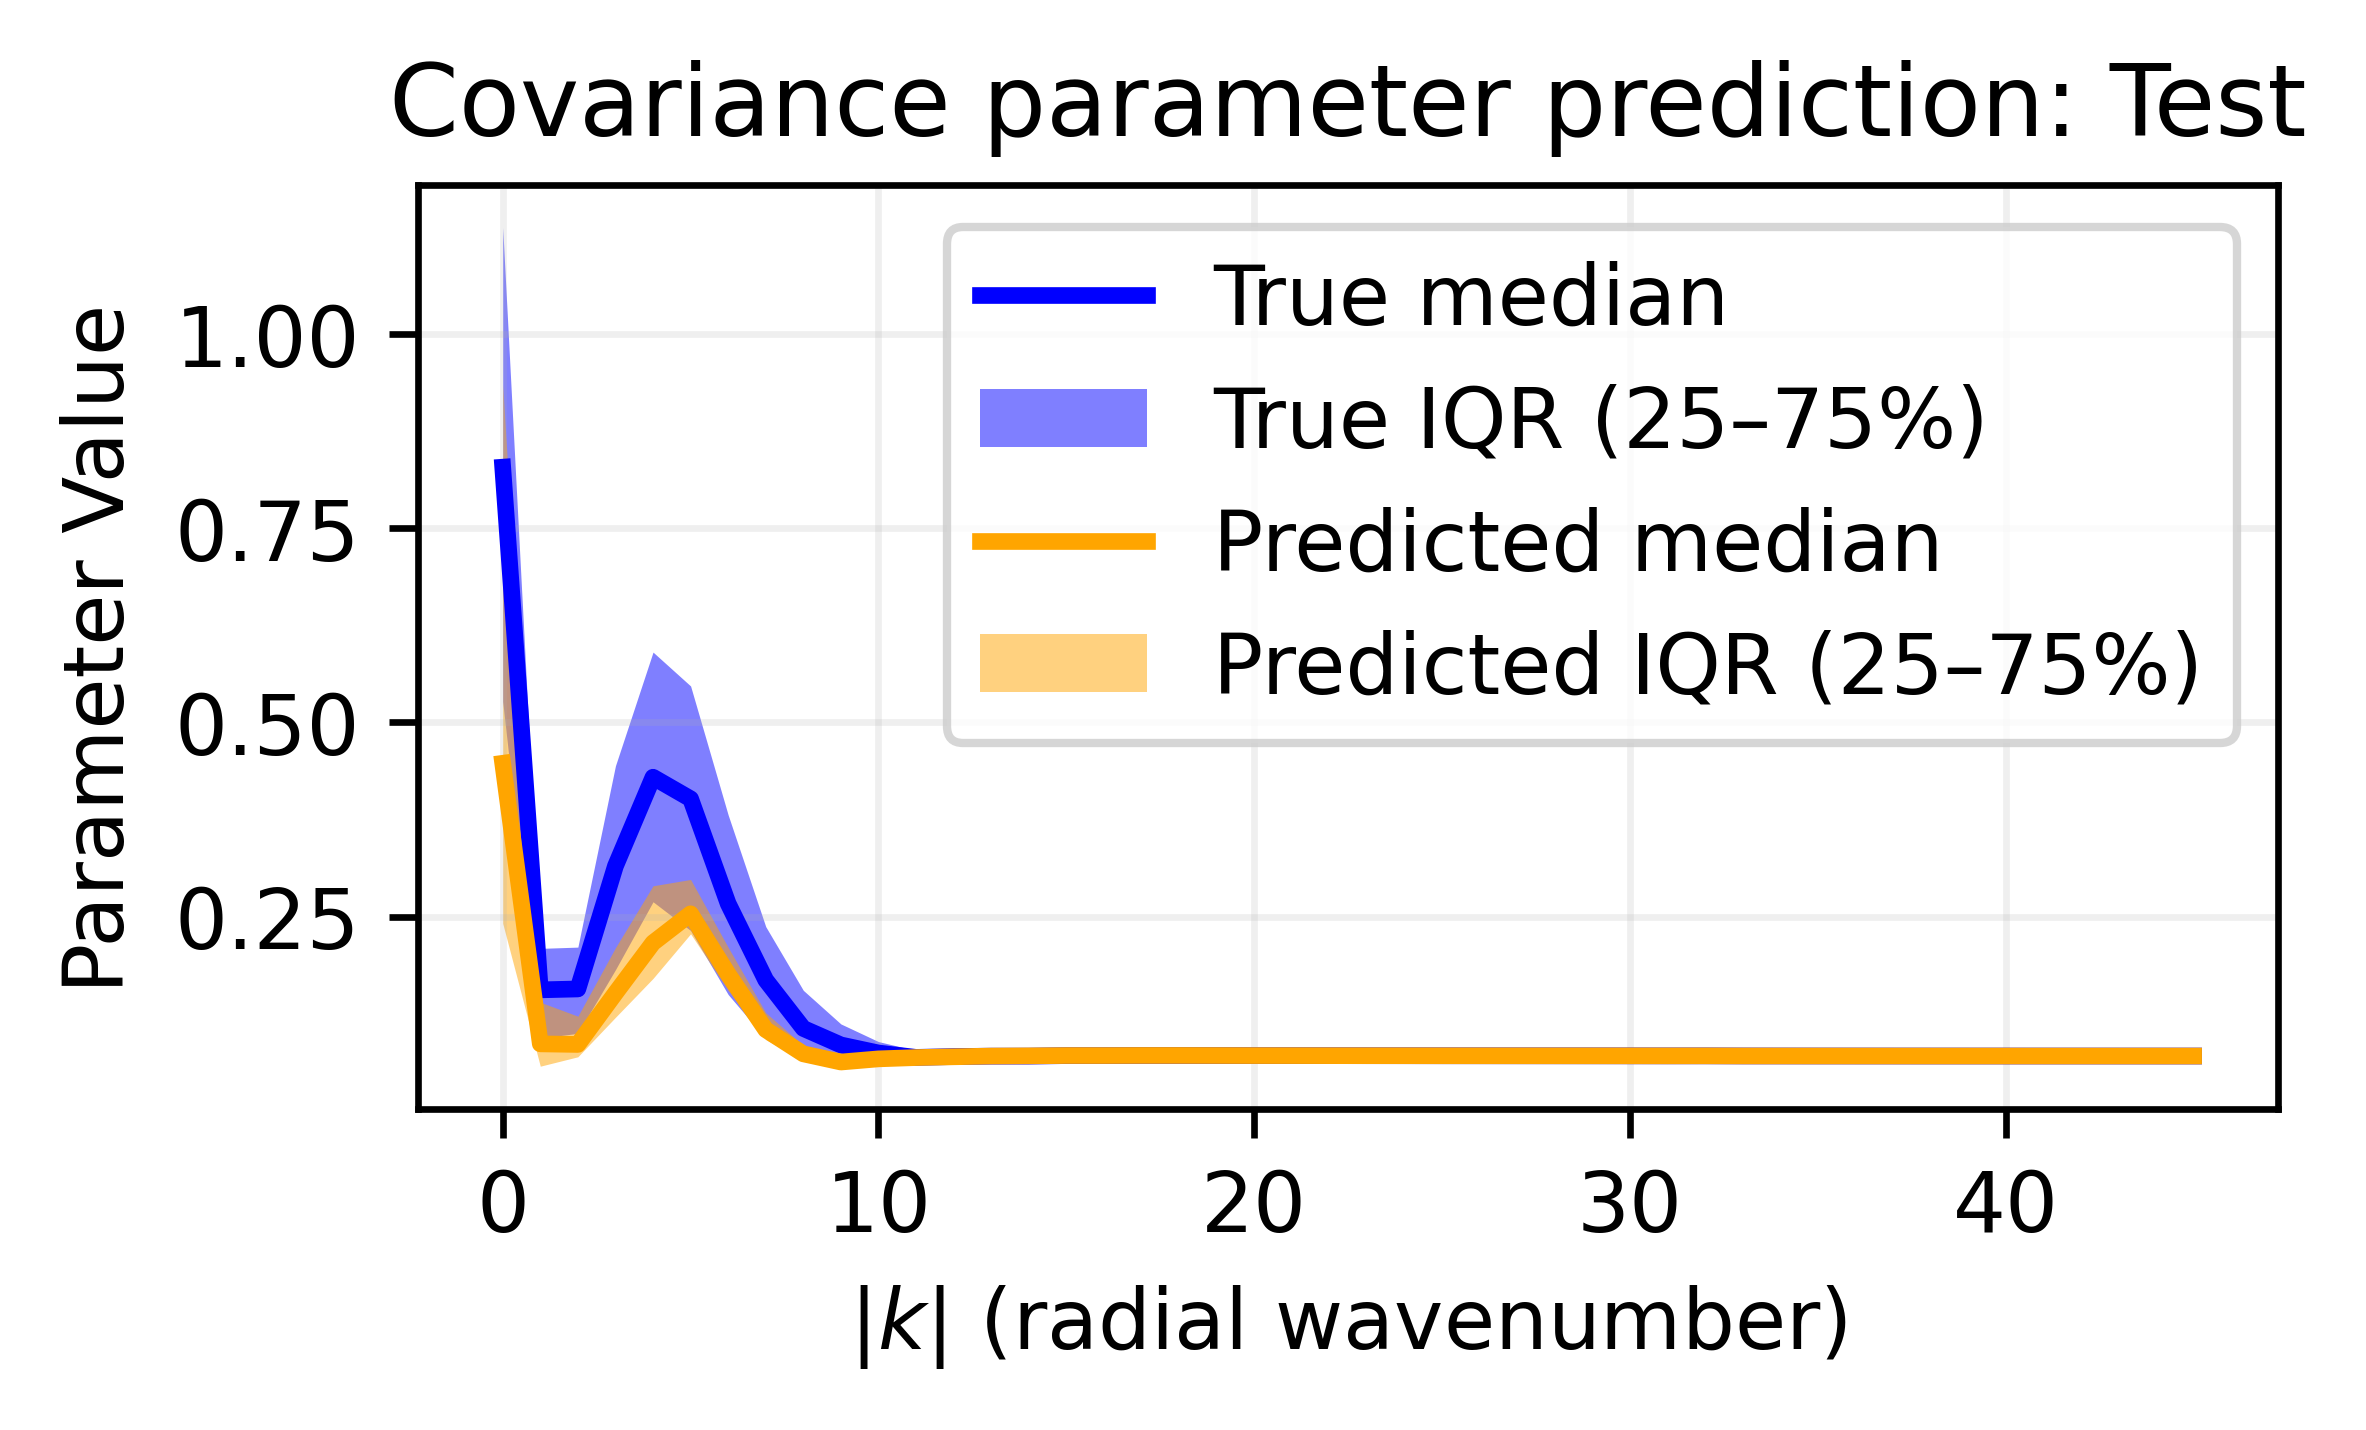

In [33]:

# ======================
# Compute radial profiles
# ======================

true_profiles = np.array([
    radial_profile(s_test_true[i]) for i in range(len(s_test_true))
])

pred_profiles = np.array([
    radial_profile(s_test[i]) for i in range(len(s_test))
])

import numpy as np
import matplotlib.pyplot as plt

# ======================
# Quantiles
# ======================

# Choose quantiles
q_lo, q_med, q_hi = 0.25, 0.50, 0.75

true_q_lo  = np.quantile(true_profiles, q_lo, axis=0)
true_q_med = np.quantile(true_profiles, q_med, axis=0)
true_q_hi  = np.quantile(true_profiles, q_hi, axis=0)

pred_q_lo  = np.quantile(pred_profiles, q_lo, axis=0)
pred_q_med = np.quantile(pred_profiles, q_med, axis=0)
pred_q_hi  = np.quantile(pred_profiles, q_hi, axis=0)

r = np.arange(len(true_q_med))

# ======================
# Plot
# ======================

plt.figure(figsize=(4, 2), dpi=600)

# --- True ---
plt.plot(
    r,
    true_q_med,
    color="blue",
    lw=2,
    label="True median",
)
plt.fill_between(
    r,
    true_q_lo,
    true_q_hi,
    color="blue",
    alpha=0.5,
    lw=0,
    label="True IQR (25–75%)",
)

# --- Predicted ---
plt.plot(
    r,
    pred_q_med,
    color="orange",
    lw=2,
    label="Predicted median",
)
plt.fill_between(
    r,
    pred_q_lo,
    pred_q_hi,
    color="orange",
    alpha=0.5,
    lw=0,
    label="Predicted IQR (25–75%)",
)

# Formatting
plt.xlabel(r"$|k|$ (radial wavenumber)")
plt.ylabel("Parameter Value")
plt.title("Covariance parameter prediction: Test")
plt.grid(alpha=0.2)
plt.legend()

# Optional for spectra
# plt.yscale("log")

# Optional: save for appendix
# plt.savefig("radial_spectrum_quantiles.pdf", bbox_inches="tight")

plt.show()


Hows the 2d fit accuracy

plot 2d maps of true vs pred
## Train

In [34]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable


In [35]:
def add_colorbar(mappable):
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

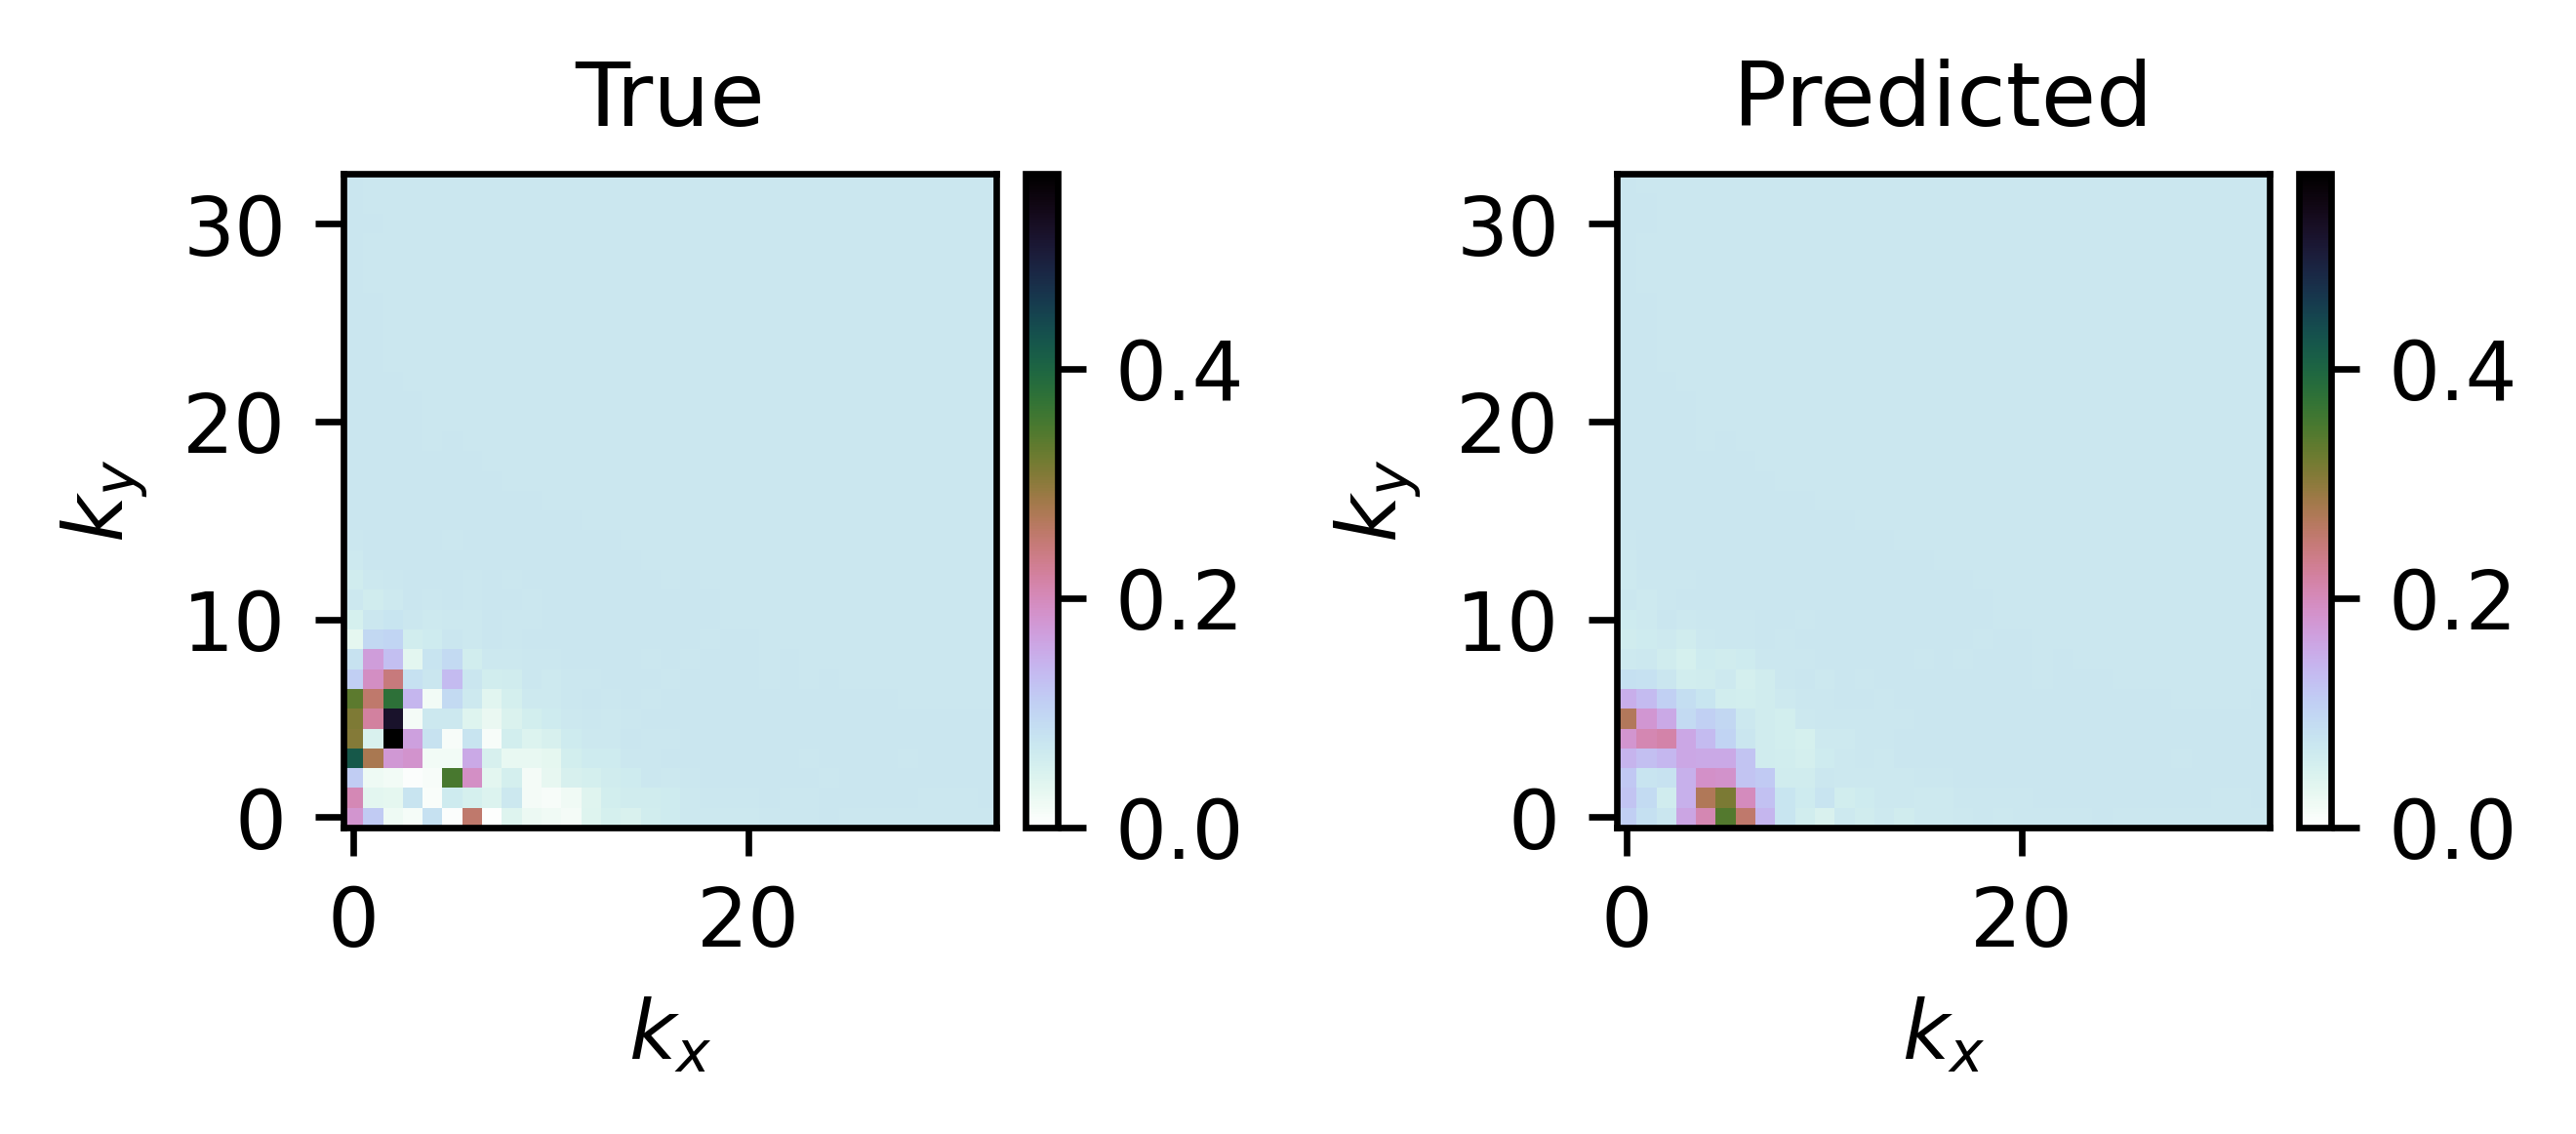

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def to_grid(v):
    return v.reshape(33, 33)

# choose which example to plot
i = 3

true_spec = to_grid(s_true[i])
pred_spec = to_grid(s_pred[i])

# color limits
vmin = 0
vmax = true_spec.max()

_h = 4.5

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(_h, _h/2),
    dpi=600,
    # constrained_layout=True,
)

# True
im = axes[0].imshow(
    true_spec,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
    cmap="cubehelix_r",
)
axes[0].set_title("True", fontsize=11)

# Predicted
im_p = axes[1].imshow(
    pred_spec,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
    cmap="cubehelix_r",
)
axes[1].set_title("Predicted", fontsize=11)

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')

# shared colorbar
# cbar = fig.colorbar(
#     im,
#     ax=axes,
#     orientation="vertical",
#     fraction=0.05,
#     pad=0.04,
# )
# cbar.set_label("Spectral power", fontsize=10)
add_colorbar(im)
add_colorbar(im_p)
# plt.subplots_adjust(wspace=.5)

plt.tight_layout()


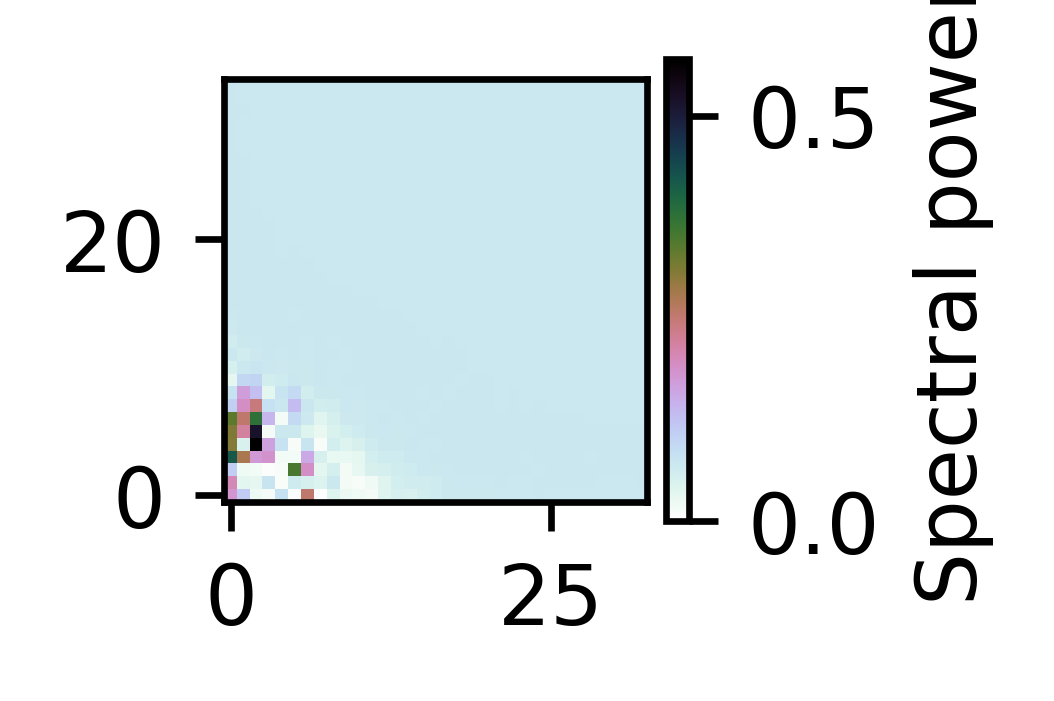

In [37]:
def plot_true(ax):
    return ax.imshow(
        true_spec,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="cubehelix_r",
    )
    # ax.set_xticks([])
    # ax.set_yticks([])


def plot_pred(ax):
    return ax.imshow(
        pred_spec,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="cubehelix_r",
    )
    # ax.set_xticks([])
    # ax.set_yticks([])

fig, ax = plt.subplots(1,1, dpi=600, figsize = (1, 1))
im = plot_true(ax)
# shared colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.05,
    pad=0.04,
)
cbar.set_label("Spectral power", fontsize=10)

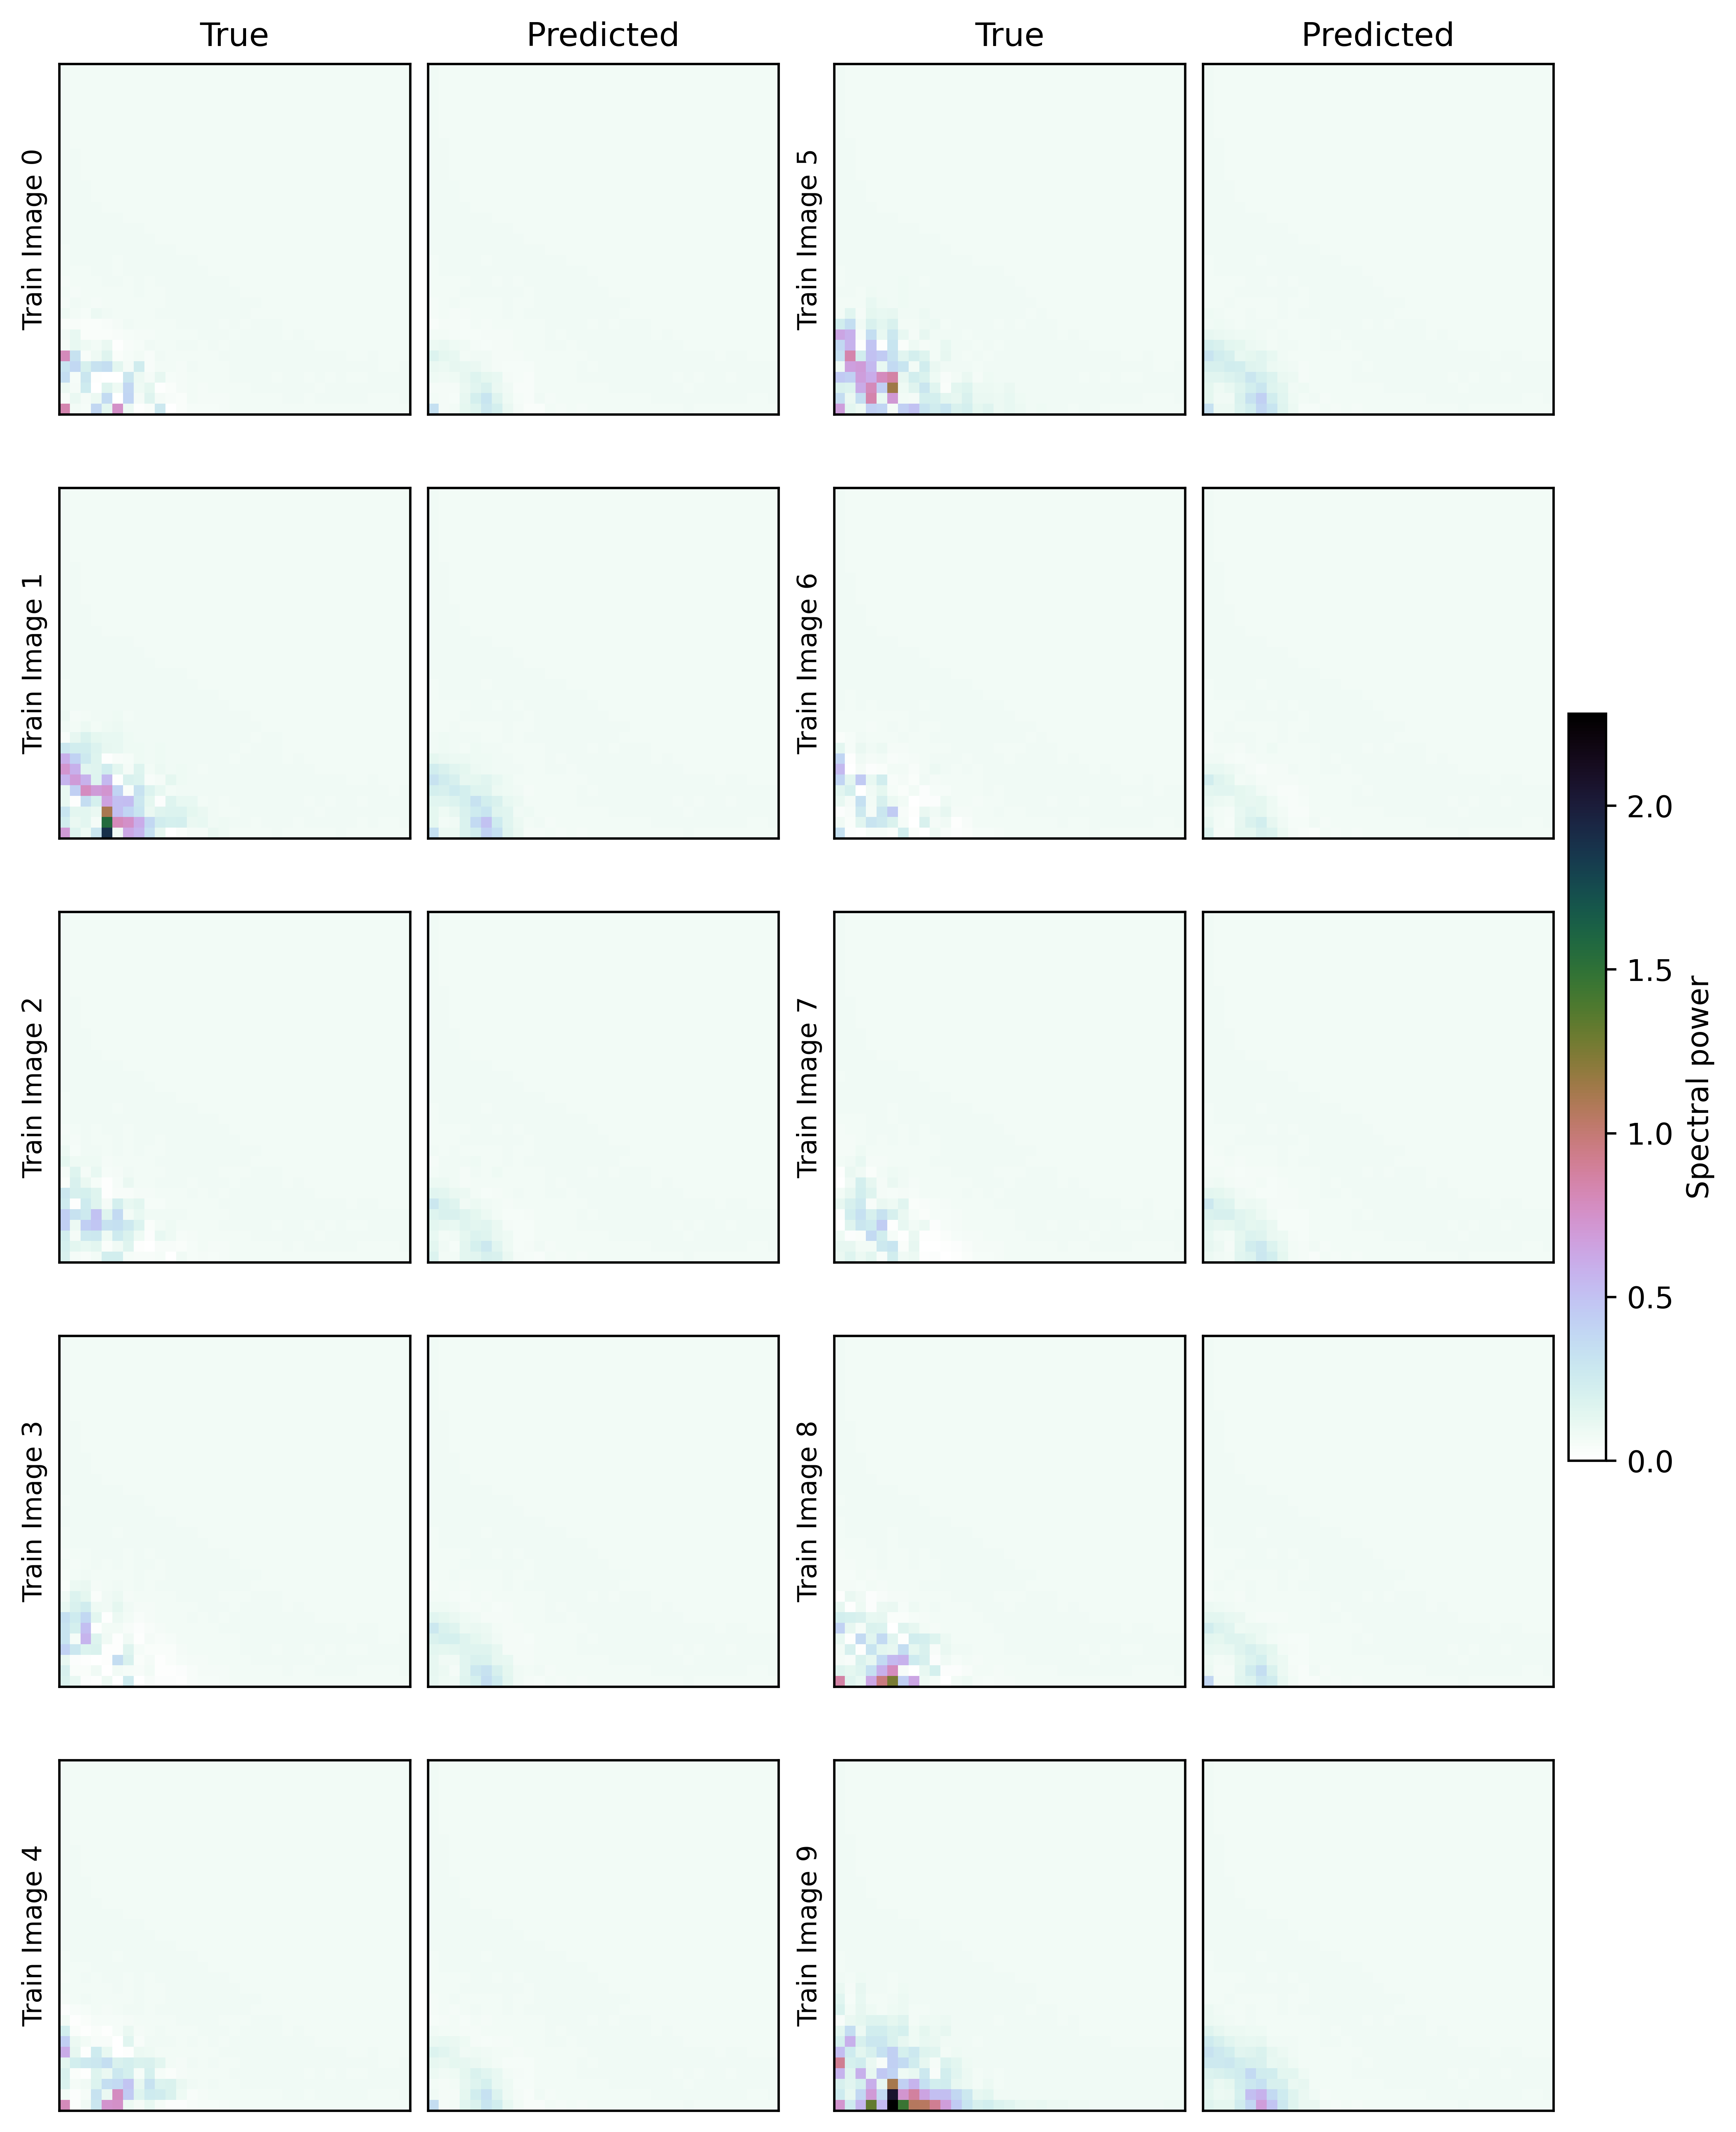

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def to_grid(v):
    return v.reshape(33, 33)

n_examples = 10
n_rows = n_examples // 2  # 5

true_specs = [to_grid(s_true[i]) for i in range(n_examples)]
pred_specs = [to_grid(s_pred[i]) for i in range(n_examples)]

# Global color limits (appendix-friendly)
# vmin = min(spec.min() for spec in true_specs)
vmin = 0
vmax = max(spec.max() for spec in true_specs)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=4,  # (True, Pred) × 2 blocks
    figsize=(8, 2.0 * n_rows),
    dpi=600,
    constrained_layout=True,
)

for i in range(n_examples):
    block = i // n_rows        # 0 = left block, 1 = right block
    row = i % n_rows
    col0 = block * 2           # starting column of this block

    ax_true = axes[row, col0]
    ax_pred = axes[row, col0 + 1]

    im = ax_true.imshow(
        true_specs[i],
        # cmap="viridis",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap = 'cubehelix_r',
    )
    ax_pred.imshow(
        pred_specs[i],
        # cmap="viridis",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap = 'cubehelix_r',
    )

    ax_true.set_ylabel(f"Train Image {i}", fontsize=9)

    for ax in (ax_true, ax_pred):
        ax.set_xticks([])
        ax.set_yticks([])

# Column titles
axes[0, 0].set_title("True", fontsize=11)
axes[0, 1].set_title("Predicted", fontsize=11)
axes[0, 2].set_title("True", fontsize=11)
axes[0, 3].set_title("Predicted", fontsize=11)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.01,
)
cbar.set_label("Spectral power", fontsize=10)

plt.show()


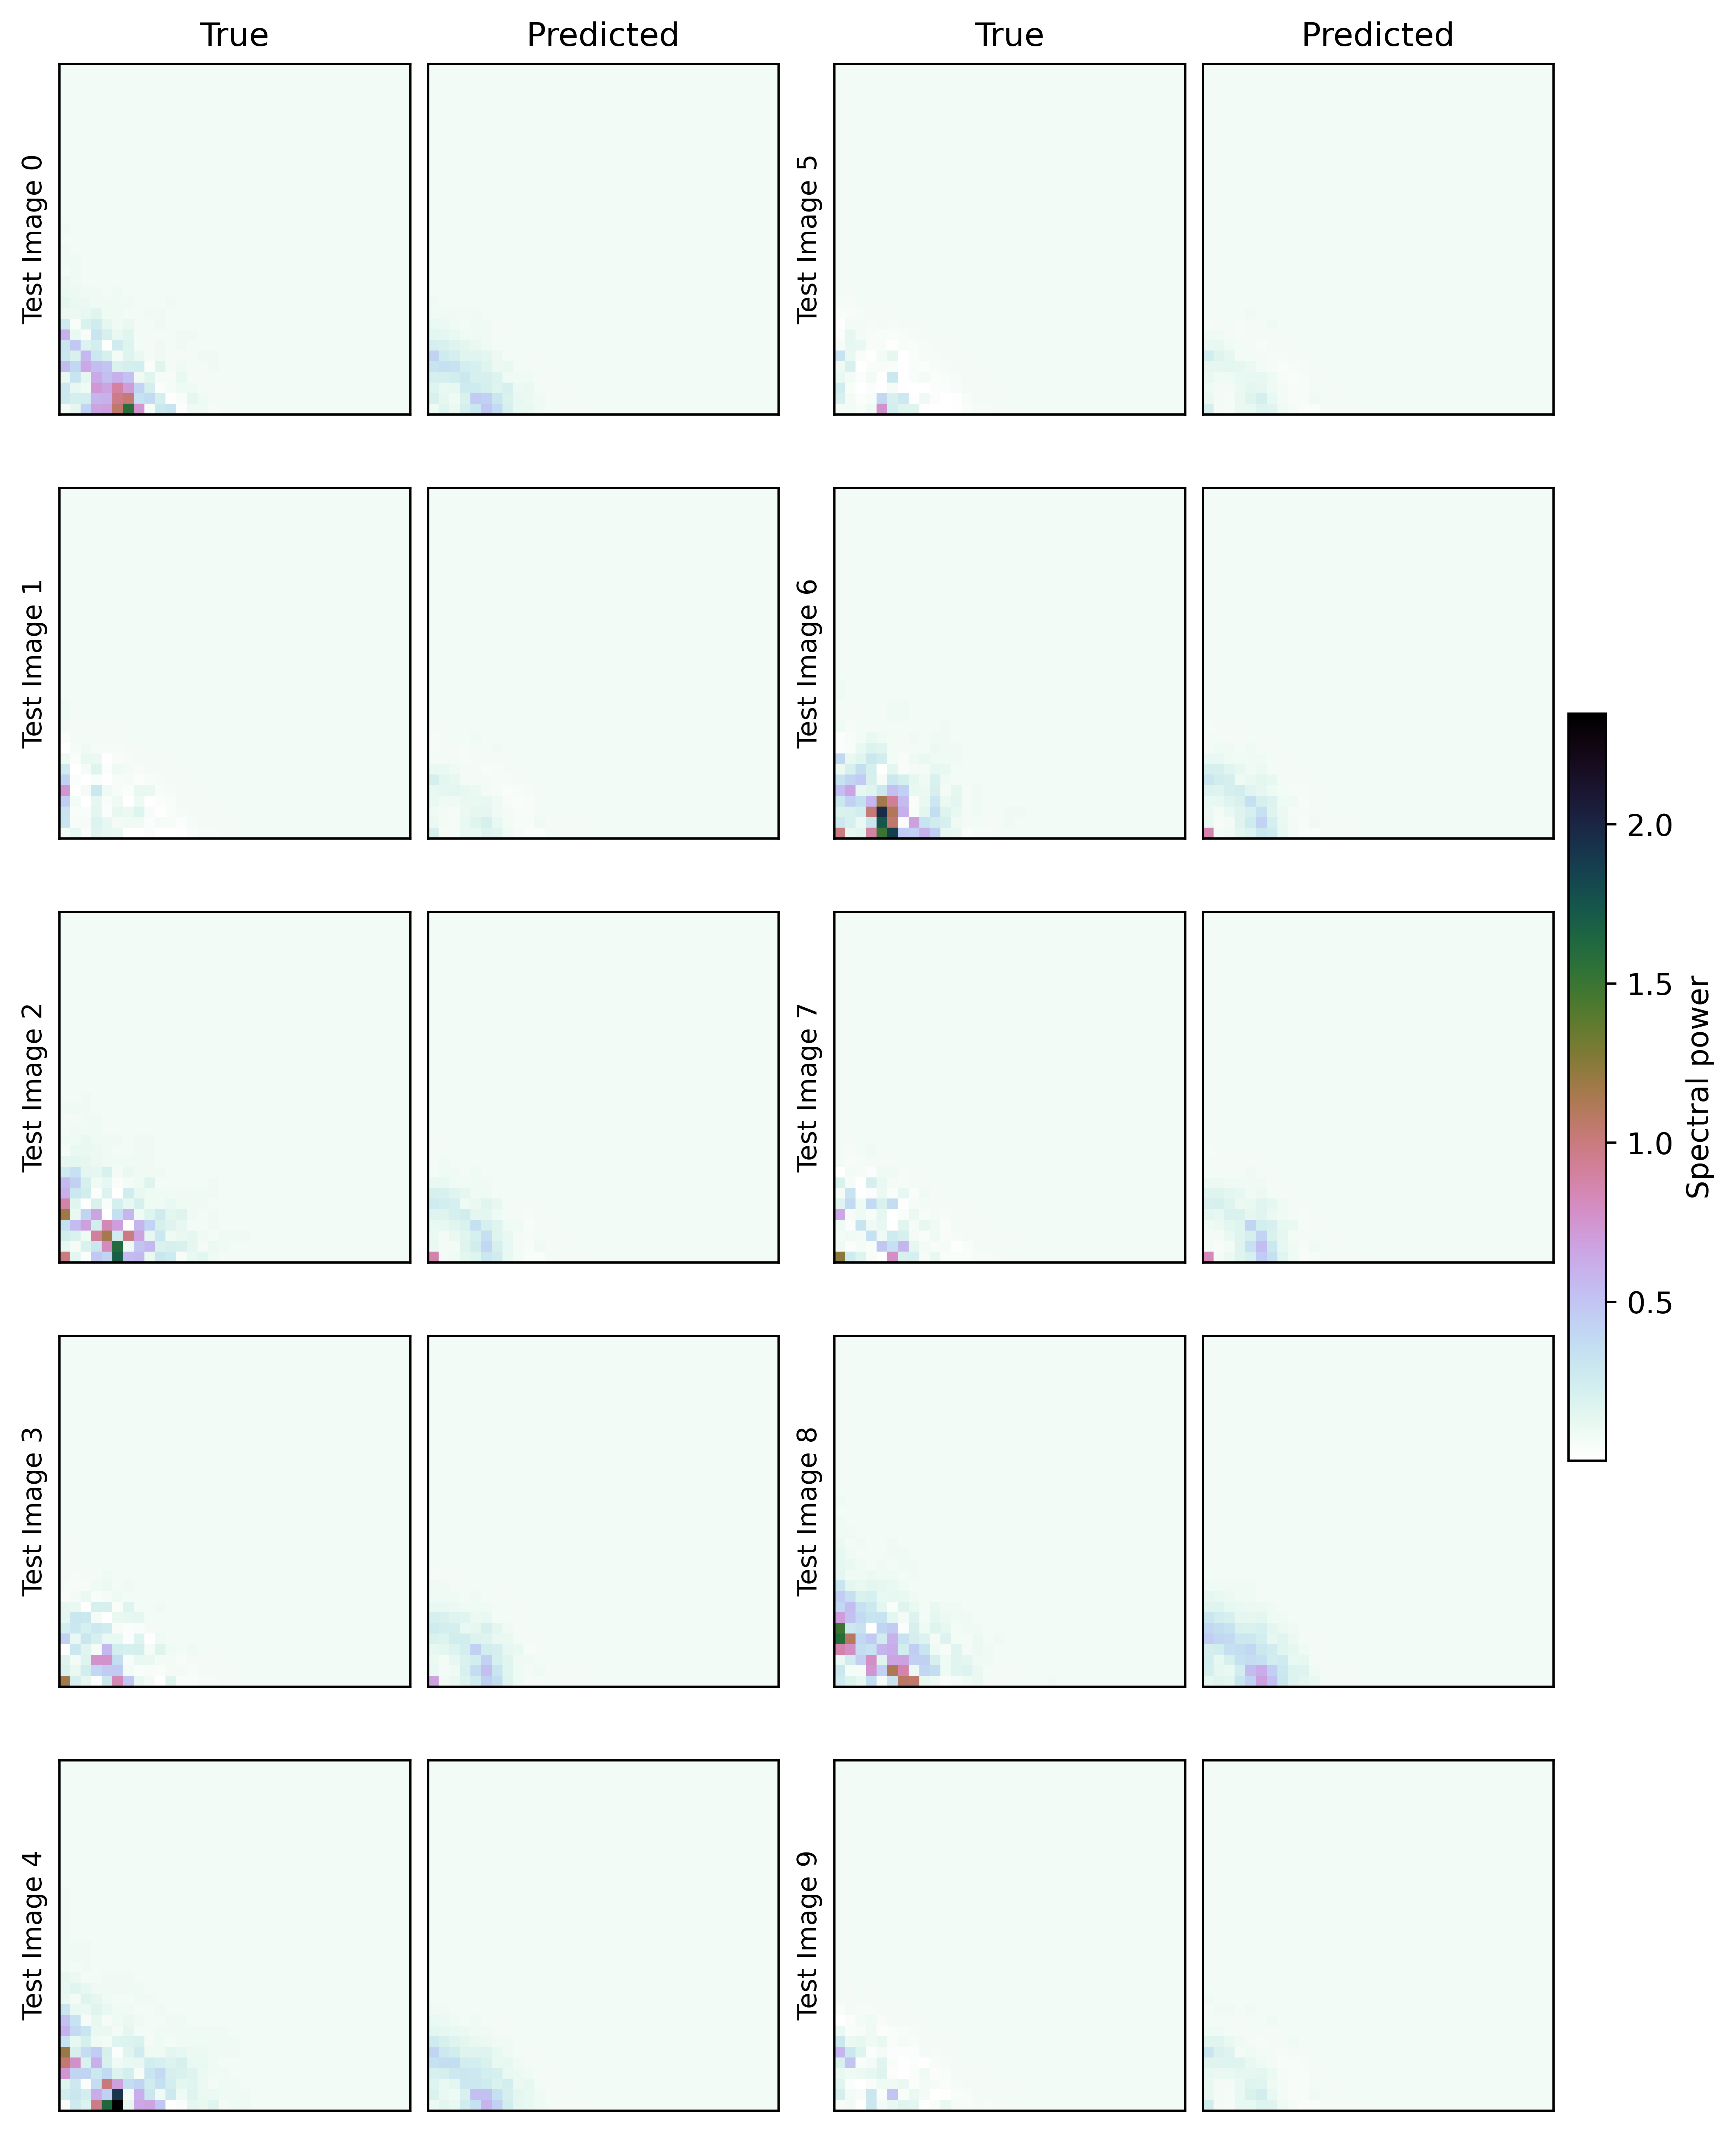

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def to_grid(v):
    return v.reshape(33, 33)

n_examples = 10
n_rows = n_examples // 2  # 5

true_specs = [to_grid(s_test_true[i]) for i in range(n_examples)]
pred_specs = [to_grid(s_test[i]) for i in range(n_examples)]

# Global color limits (appendix-friendly)
vmin = min(spec.min() for spec in true_specs)
vmax = max(spec.max() for spec in true_specs)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=4,  # (True, Pred) × 2 blocks
    figsize=(8, 2.0 * n_rows),
    dpi=600,
    constrained_layout=True,
)

for i in range(n_examples):
    block = i // n_rows        # 0 = left block, 1 = right block
    row = i % n_rows
    col0 = block * 2           # starting column of this block

    ax_true = axes[row, col0]
    ax_pred = axes[row, col0 + 1]

    im = ax_true.imshow(
        true_specs[i],
        cmap = 'cubehelix_r',
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    ax_pred.imshow(
        pred_specs[i],
        cmap = 'cubehelix_r',
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    ax_true.set_ylabel(f"Test Image {i}", fontsize=9)

    for ax in (ax_true, ax_pred):
        ax.set_xticks([])
        ax.set_yticks([])

# Column titles
axes[0, 0].set_title("True", fontsize=11)
axes[0, 1].set_title("Predicted", fontsize=11)
axes[0, 2].set_title("True", fontsize=11)
axes[0, 3].set_title("Predicted", fontsize=11)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.01,
)
cbar.set_label("Spectral power", fontsize=10)

plt.show()


plot 2d maps of true vs pred
## test

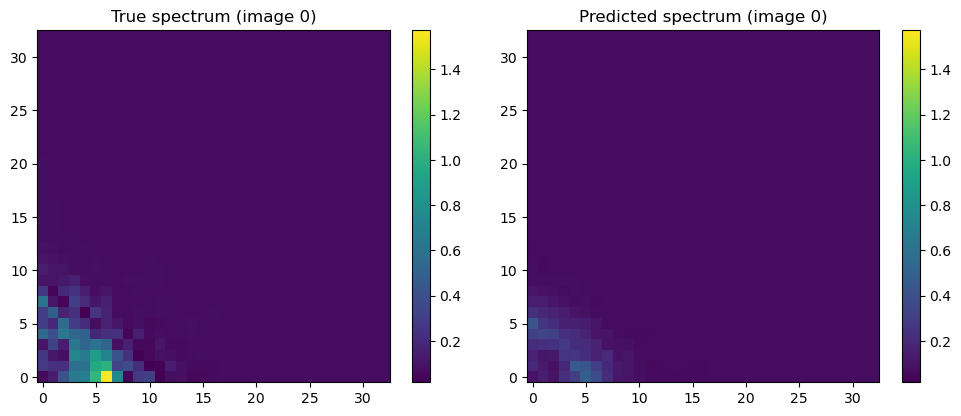

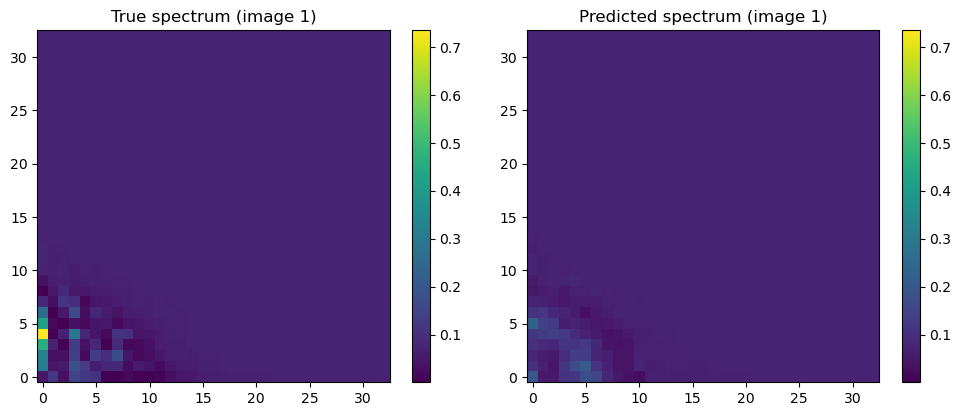

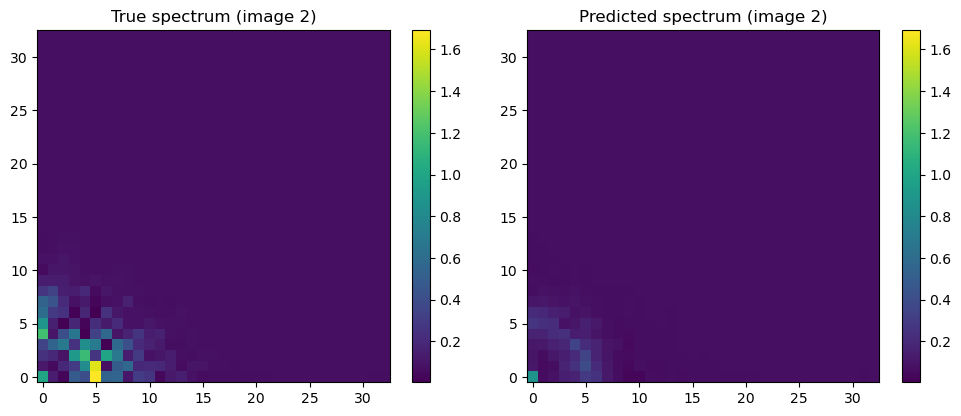

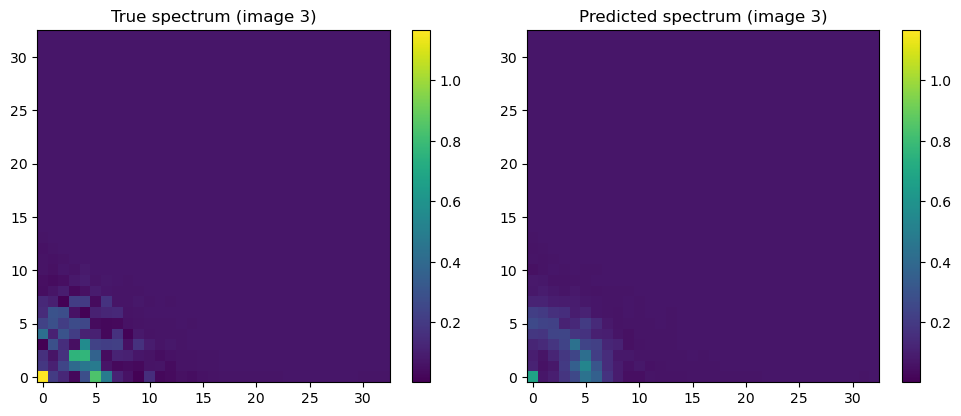

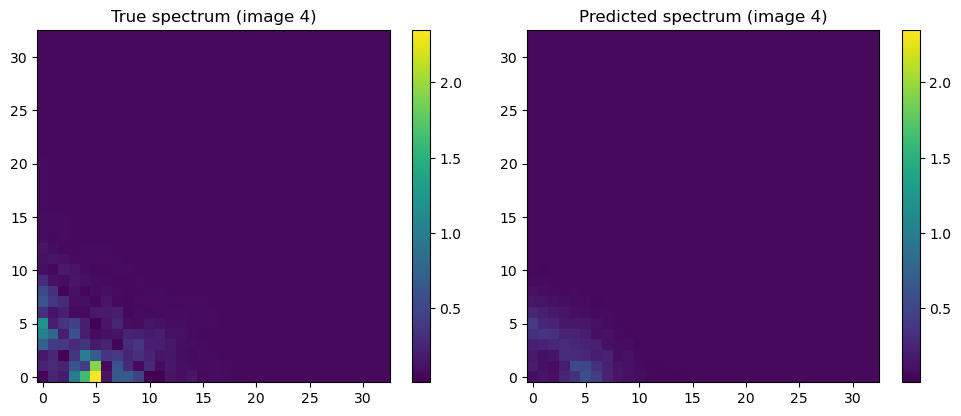

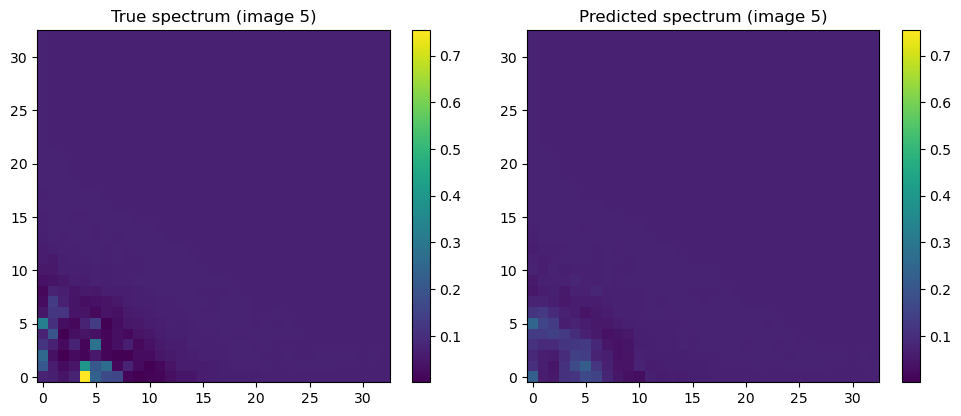

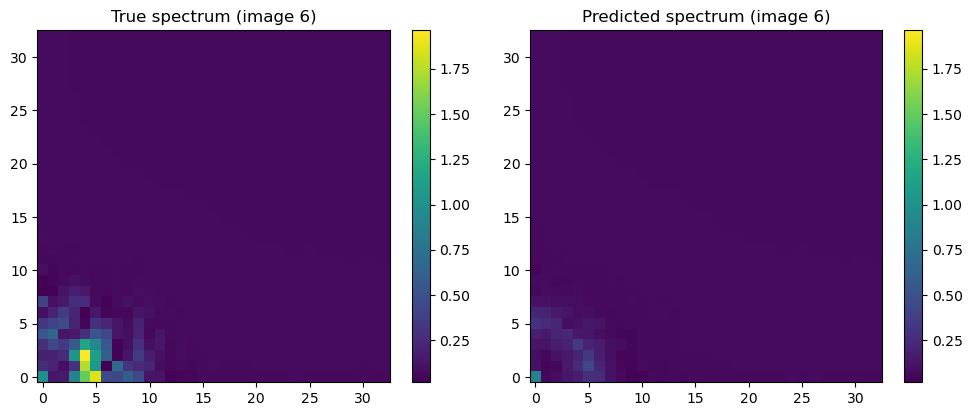

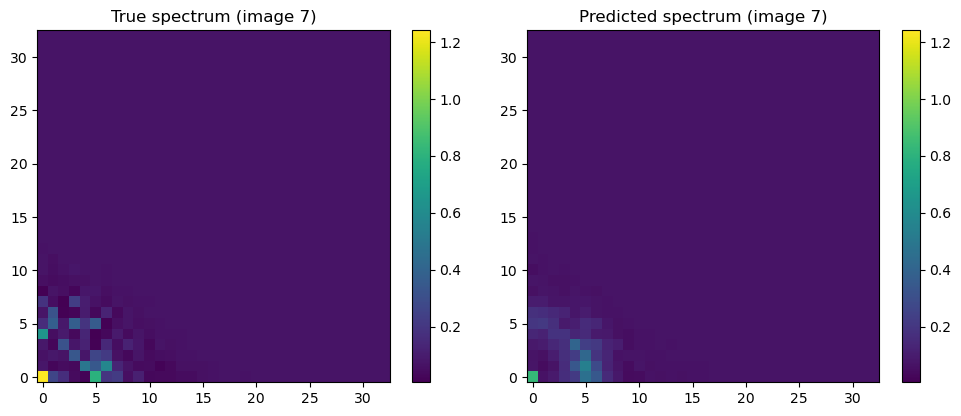

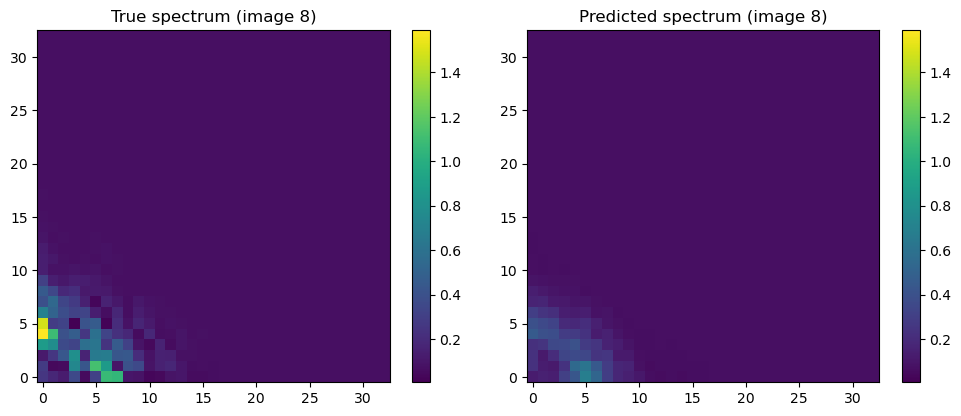

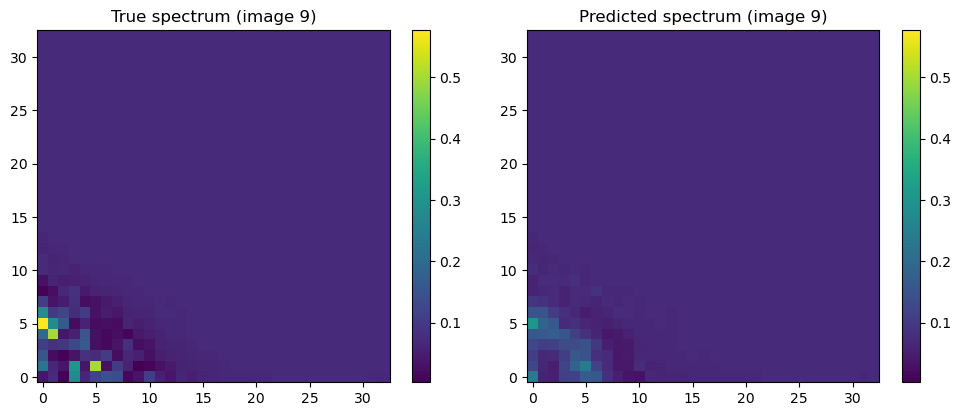

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def to_grid(v):
    return v.reshape(33,33)

for i in range(10):

    true_spec = to_grid(s_test_true[i])
    pred_spec = to_grid(s_test[i])

    vmin = true_spec.min()
    vmax = true_spec.max()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    im0 = plt.imshow(
        true_spec,
        cmap='viridis',
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    plt.title(f"True spectrum (image {i})")
    plt.colorbar(im0)

    plt.subplot(1,2,2)
    im1 = plt.imshow(
        pred_spec,
        cmap='viridis',
        origin='lower',
        vmin=vmin,
        vmax=vmax
    )
    plt.title(f"Predicted spectrum (image {i})")
    plt.colorbar(im1)

    plt.tight_layout()
    plt.show()


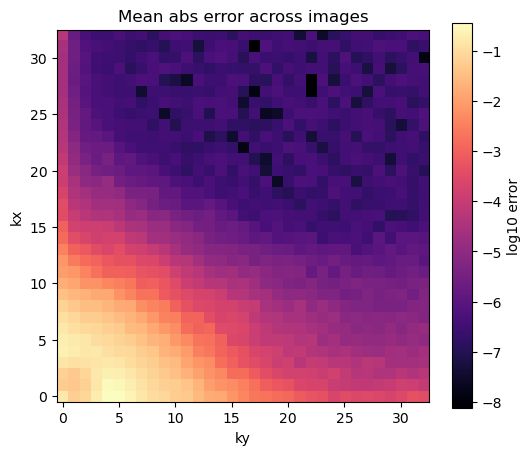

In [47]:
err_all = np.mean(np.abs(s_pred - s_true), axis=0).reshape(33,33)

plt.figure(figsize=(6,5))
plt.imshow(np.log10(err_all + 1e-12), cmap='magma', origin='lower')
plt.title("Mean abs error across images")
plt.colorbar(label="log10 error")
plt.xlabel("ky")
plt.ylabel("kx")
plt.show()


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/hgoldwyn/opt/anaconda3/envs/torch/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/hgoldwyn/opt/anaconda3/envs/torch/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


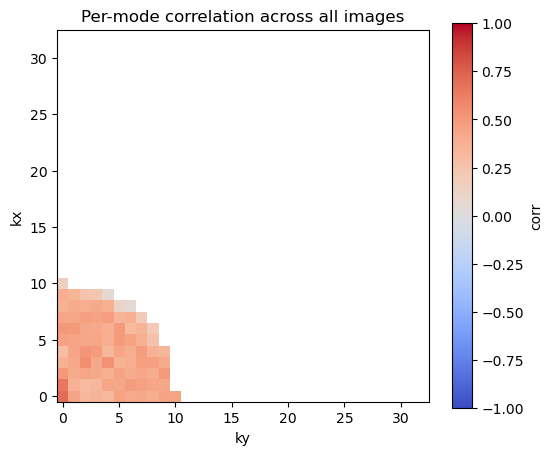

In [48]:
corr_map = np.zeros(1089)
for k in range(1089):
    corr_map[k] = np.corrcoef(s_true[:,k], s_pred[:,k])[0,1]

plt.figure(figsize=(6,5))
plt.imshow(corr_map.reshape(33,33), cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
plt.title("Per-mode correlation across all images")
plt.colorbar(label="corr")
plt.xlabel("ky")
plt.ylabel("kx")
plt.show()


## Plot image-specific covariances asw f(r)

In [84]:
mode_response = np.load("../analysis/fourier_sep_per_mode.npy")

In [85]:
true_test_cov_vs_r = s_test_true @ mode_response.T
pred_test_cov_vs_r = s_test @ mode_response.T

In [88]:
kappa = '0.5'

In [94]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from matplotlib.lines import Line2D


# plt.figure(dpi=600, figsize=(4, 2))

# _x = range(true_test_cov_vs_r.shape[1])

# # Main plot: full y-range (no "slim restrictions")
# plt.plot(_x, true_test_cov_vs_r.mean(axis=0), color='k', ls='--', lw=1, label='global covariance')
# for i, cov in enumerate(true_test_cov_vs_r):
#     _label = 'individual img-specific cov.s' if i == 0 else None
#     plt.plot(_x, cov, alpha=0.7, color='gray', zorder=0, lw=0.1, label=_label)

# plt.ylabel('Cov')
# plt.xlabel('Pixel separation')
# plt.ylim(true_test_cov_vs_r.min(), true_test_cov_vs_r.max())  # full range
# ax = plt.gca()

# # ~~~ Inset axes with slim y-axis range ~~~
# ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper center',
#                       bbox_to_anchor=(0.05, -0.125, 1, 1), bbox_transform=plt.gcf().transFigure)

# ax_inset.plot(_x, true_test_cov_vs_r.mean(axis=0), color='k', ls='--', lw=1)
# for cov in true_test_cov_vs_r:
#     ax_inset.plot(_x, cov, alpha=0.7, color='gray', zorder=0, lw=0.1)

# ax_inset.set_ylim(-0.0015, 0.003)  # slim view
# ax_inset.set_xlim(_x[0], _x[-1])  # optional: match full x-range
# ax_inset.tick_params(labelsize=6)
# # ax_inset.set_title("Zoom", fontsize=8)

# ## Plot regularized output
# for _ax in [ax, ax_inset]:
#     # _ax.plot(range(90), covs_np_p2p5.mean(axis=0), color='k', label='mean')
#     # _ax.plot(range(90), np.median(covs_np_p2p5, axis=0), color='C0', label='median')

#     for i, cov in enumerate(pred_test_cov_vs_r):
#         if i == 0:
#             _label = 'individual img-specific cov.s'
#         else:
#             _label = None
#         _ax.plot(range(90), cov, alpha=0.7, color='C0', zorder = 0, lw=0.1, label=_label)

# custom_handles = [
#     Line2D([0], [0], color='black', linewidth=1, label='Global cov'),
#     Line2D([], [], color='gray', linewidth=0.5, label='Unregularized img-specific covs'),
#     Line2D([], [], color='C0', linewidth=0.5, label=f'Regularized (SF={kappa}) img-specific covs'),
# ]
# ax_inset.legend(handles=custom_handles, loc='upper center', fontsize=4, frameon=True)

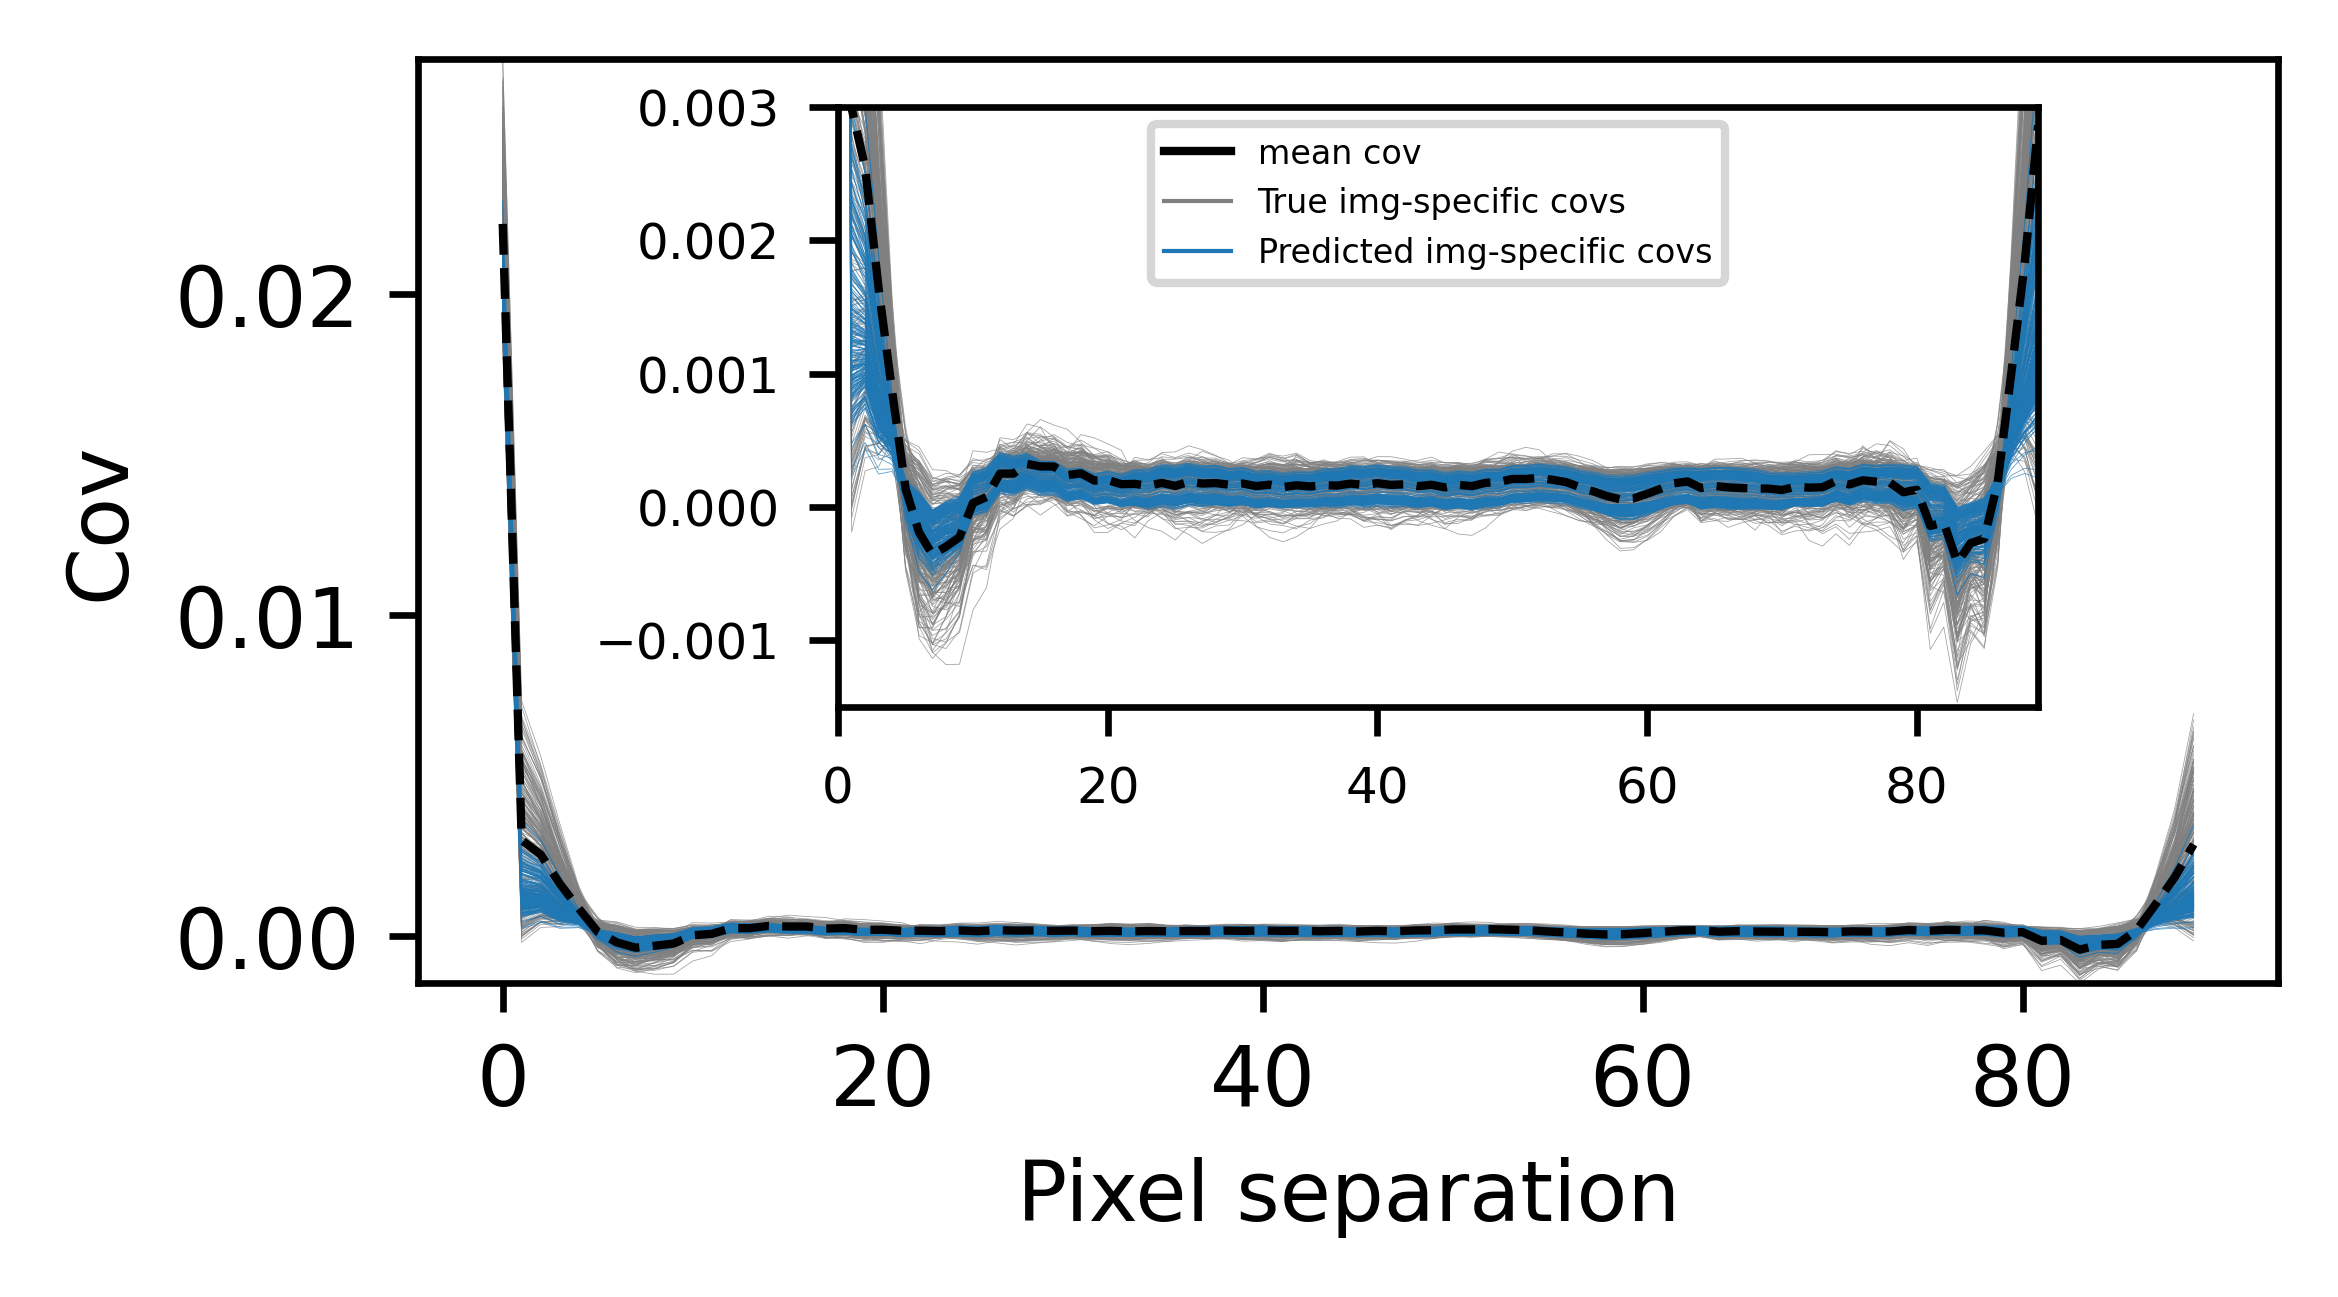

In [95]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
import numpy as np


def plot_cov_bundle(ax, x, covs, color, lw=0.1, alpha=0.7, label=None):
    """Plot many covariance curves with optional first-label."""
    for i, cov in enumerate(covs):
        ax.plot(
            x, cov,
            color=color,
            lw=lw,
            alpha=alpha,
            zorder=0,
            label=label if i == 0 else None
        )


# ------------------------------------------------------------
# Figure + axes
# ------------------------------------------------------------
plt.figure(dpi=600, figsize=(4, 2))
ax = plt.gca()

_x = np.arange(true_test_cov_vs_r.shape[1])

# ------------------------------------------------------------
# Main plot
# ------------------------------------------------------------
ax.plot(
    _x,
    true_test_cov_vs_r.mean(axis=0),
    color='k',
    ls='--',
    lw=1,
    label='mean'
)

plot_cov_bundle(
    ax,
    _x,
    true_test_cov_vs_r,
    color='gray',
    label='true img-specific cov.s'
)

ax.set_xlabel('Pixel separation')
ax.set_ylabel('Cov')
ax.set_ylim(true_test_cov_vs_r.min(), true_test_cov_vs_r.max())

# ------------------------------------------------------------
# Inset plot (zoomed y-range)
# ------------------------------------------------------------
ax_inset = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc='upper center',
    bbox_to_anchor=(0.05, -0.125, 1, 1),
    bbox_transform=plt.gcf().transFigure,
)

ax_inset.plot(
    _x,
    true_test_cov_vs_r.mean(axis=0),
    color='k',
    ls='--',
    lw=1
)

plot_cov_bundle(
    ax_inset,
    _x,
    true_test_cov_vs_r,
    color='gray'
)

ax_inset.set_ylim(-0.0015, 0.003)
ax_inset.set_xlim(_x[0], _x[-1])
ax_inset.tick_params(labelsize=6)

# ------------------------------------------------------------
# Regularized predictions (both axes)
# ------------------------------------------------------------
for _ax in (ax, ax_inset):
    plot_cov_bundle(
        _ax,
        np.arange(pred_test_cov_vs_r.shape[1]),
        pred_test_cov_vs_r,
        color='C0',
        label='predicted img-specific cov.s'
    )

# ------------------------------------------------------------
# Legend (custom handles)
# ------------------------------------------------------------
custom_handles = [
    Line2D([0], [0], color='black', lw=1, label='mean cov'),
    Line2D([], [], color='gray', lw=0.5, label='True img-specific covs'),
    Line2D([], [], color='C0', lw=0.5,
           label=f'Predicted img-specific covs'),
]

ax_inset.legend(
    handles=custom_handles,
    loc='upper center',
    fontsize=4,
    frameon=True
)

plt.show()


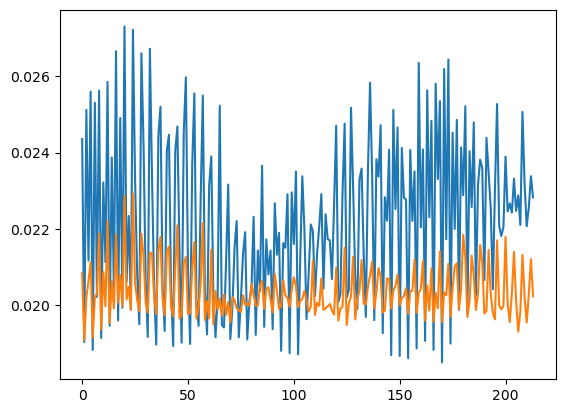

In [ ]:
plt.plot(true_test_cov_vs_r[:, 0], )
plt.plot(pred_test_cov_vs_r[:, 0], )

In [90]:
true_test_cov_vs_r.shape

(214, 90)

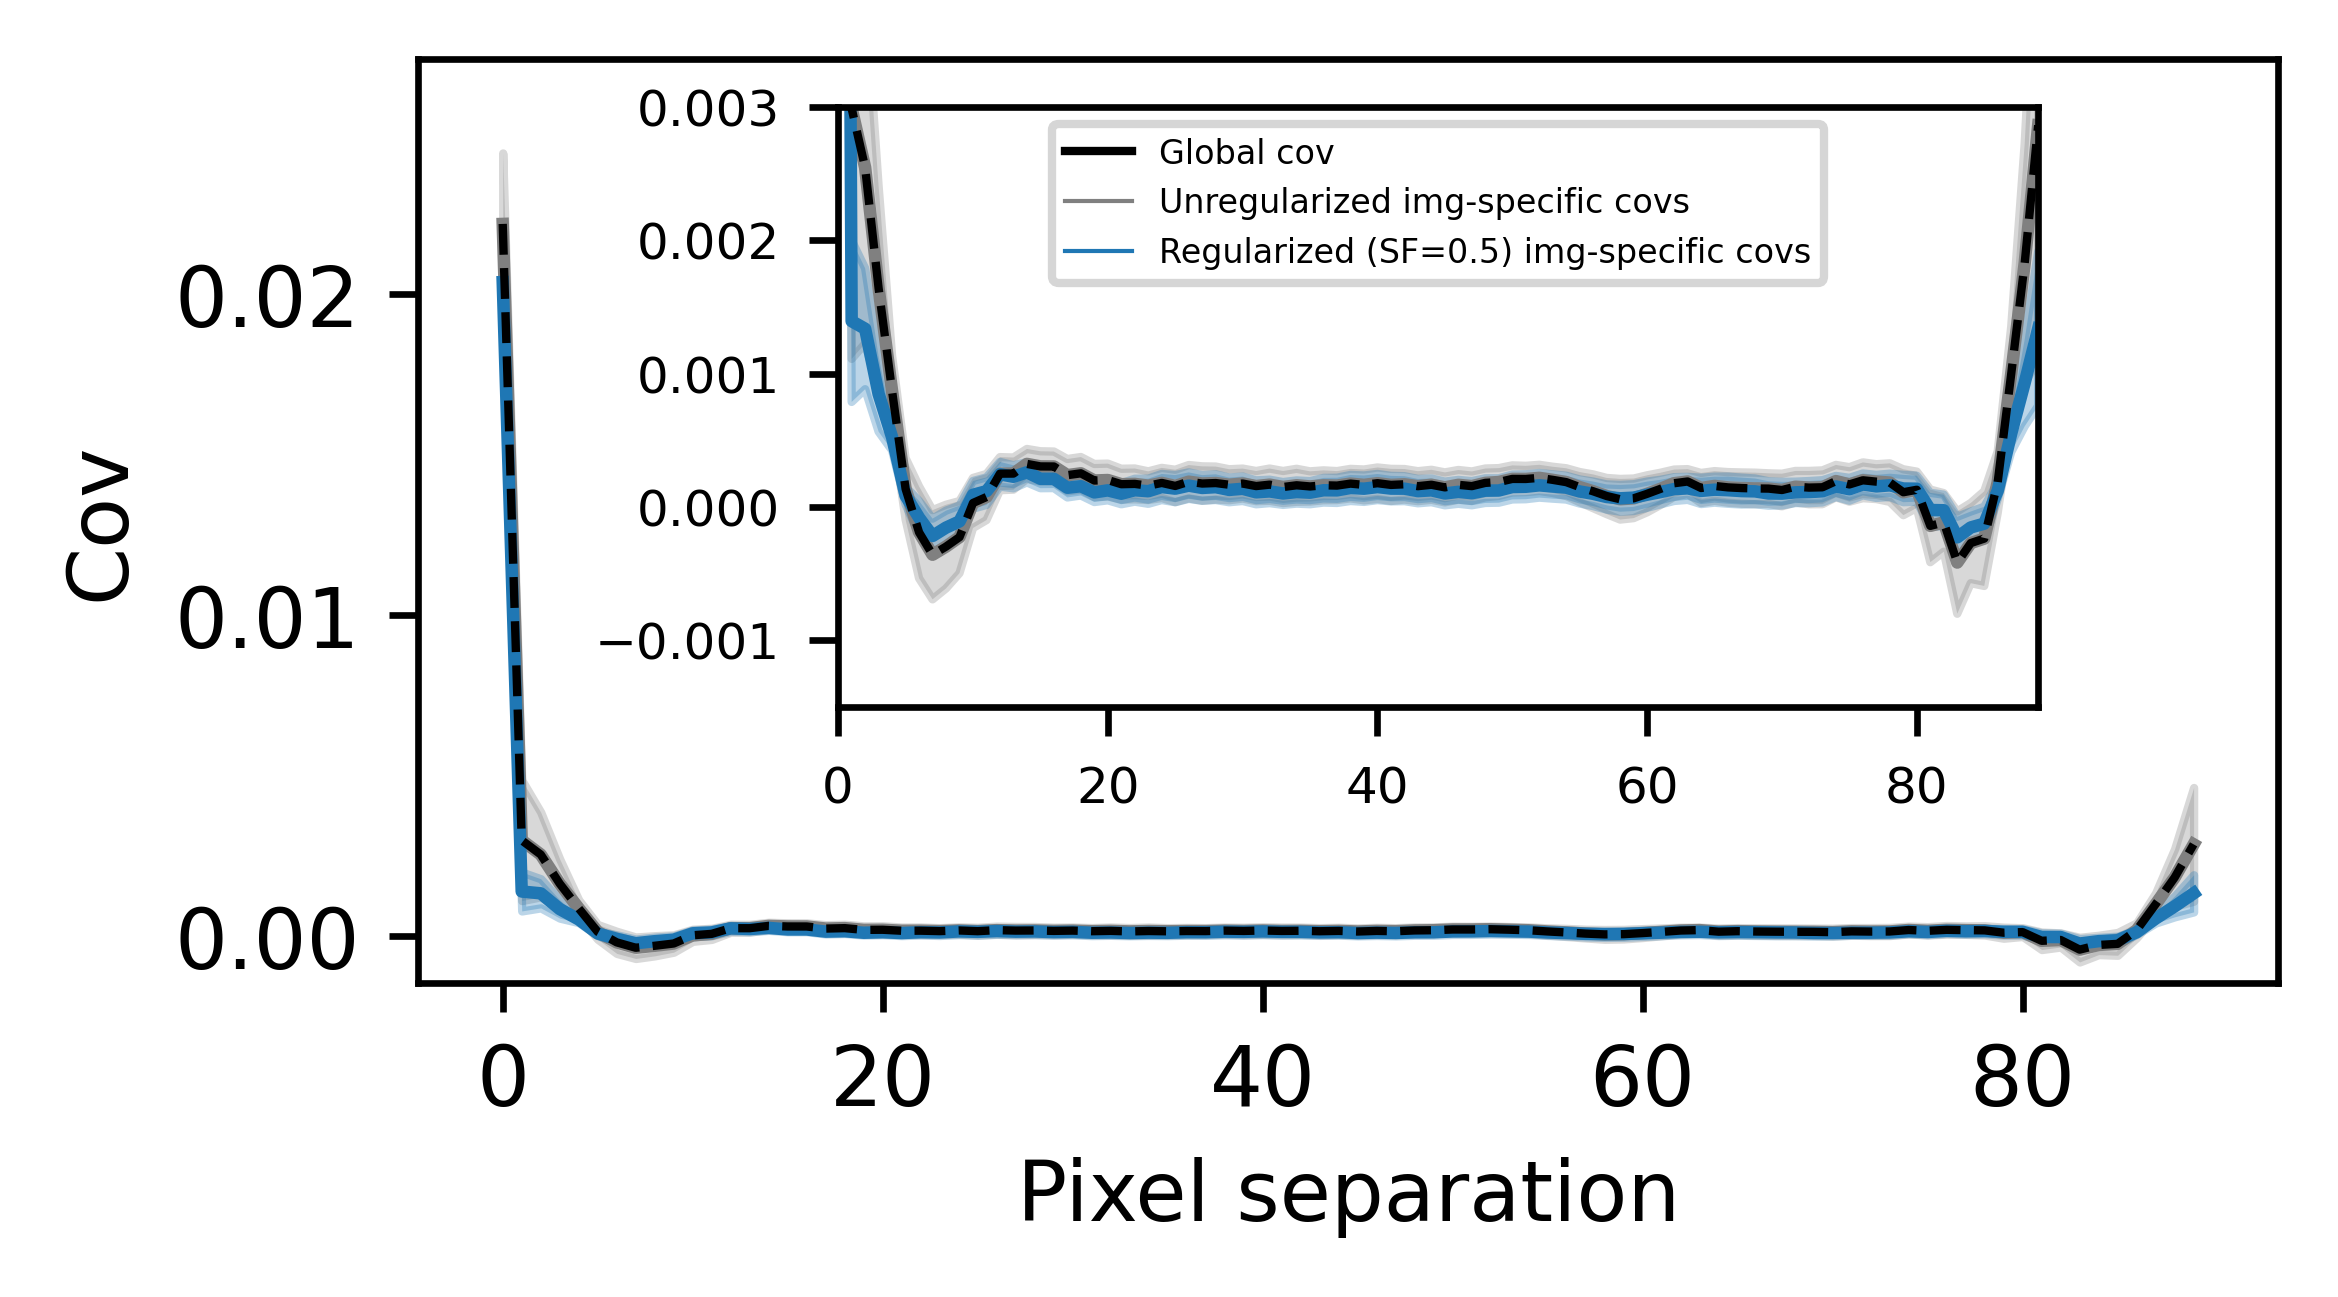

In [96]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
import numpy as np

def plot_cov_band(ax, x, covs, color, alpha=0.3, lw=1.5, label=None):
    mean = covs.mean(axis=0)
    std  = covs.std(axis=0)

    ax.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=alpha,
        zorder=0,
        label=label
    )
    ax.plot(x, mean, color=color, lw=lw, zorder=1)


# ------------------------------------------------------------
# Figure + axes
# ------------------------------------------------------------
plt.figure(dpi=600, figsize=(4, 2))
ax = plt.gca()

_x = np.arange(true_test_cov_vs_r.shape[1])

# ------------------------------------------------------------
# Main plot
# ------------------------------------------------------------
ax.plot(
    _x,
    true_test_cov_vs_r.mean(axis=0),
    color='k',
    ls='--',
    lw=1,
    label='global covariance'
)

plot_cov_band(
    ax,
    _x,
    true_test_cov_vs_r,
    color='gray',
    label='individual img-specific cov.s'
)

ax.set_xlabel('Pixel separation')
ax.set_ylabel('Cov')
ax.set_ylim(true_test_cov_vs_r.min(), true_test_cov_vs_r.max())

# ------------------------------------------------------------
# Inset plot (zoomed y-range)
# ------------------------------------------------------------
ax_inset = inset_axes(
    ax,
    width="50%",
    height="50%",
    loc='upper center',
    bbox_to_anchor=(0.05, -0.125, 1, 1),
    bbox_transform=plt.gcf().transFigure,
)

ax_inset.plot(
    _x,
    true_test_cov_vs_r.mean(axis=0),
    color='k',
    ls='--',
    lw=1
)

plot_cov_band(
    ax_inset,
    _x,
    true_test_cov_vs_r,
    color='gray'
)

ax_inset.set_ylim(-0.0015, 0.003)
ax_inset.set_xlim(_x[0], _x[-1])
ax_inset.tick_params(labelsize=6)

# ------------------------------------------------------------
# Regularized predictions (both axes)
# ------------------------------------------------------------
for _ax in (ax, ax_inset):
    plot_cov_band(
        _ax,
        np.arange(pred_test_cov_vs_r.shape[1]),
        pred_test_cov_vs_r,
        color='C0',
        label='regularized img-specific cov.s'
    )

# ------------------------------------------------------------
# Legend (custom handles)
# ------------------------------------------------------------
custom_handles = [
    Line2D([0], [0], color='black', lw=1, label='Global cov'),
    Line2D([], [], color='gray', lw=0.5, label='Unregularized img-specific covs'),
    Line2D([], [], color='C0', lw=0.5,
           label=f'Regularized (SF={kappa}) img-specific covs'),
]

ax_inset.legend(
    handles=custom_handles,
    loc='upper center',
    fontsize=4,
    frameon=True
)

plt.show()


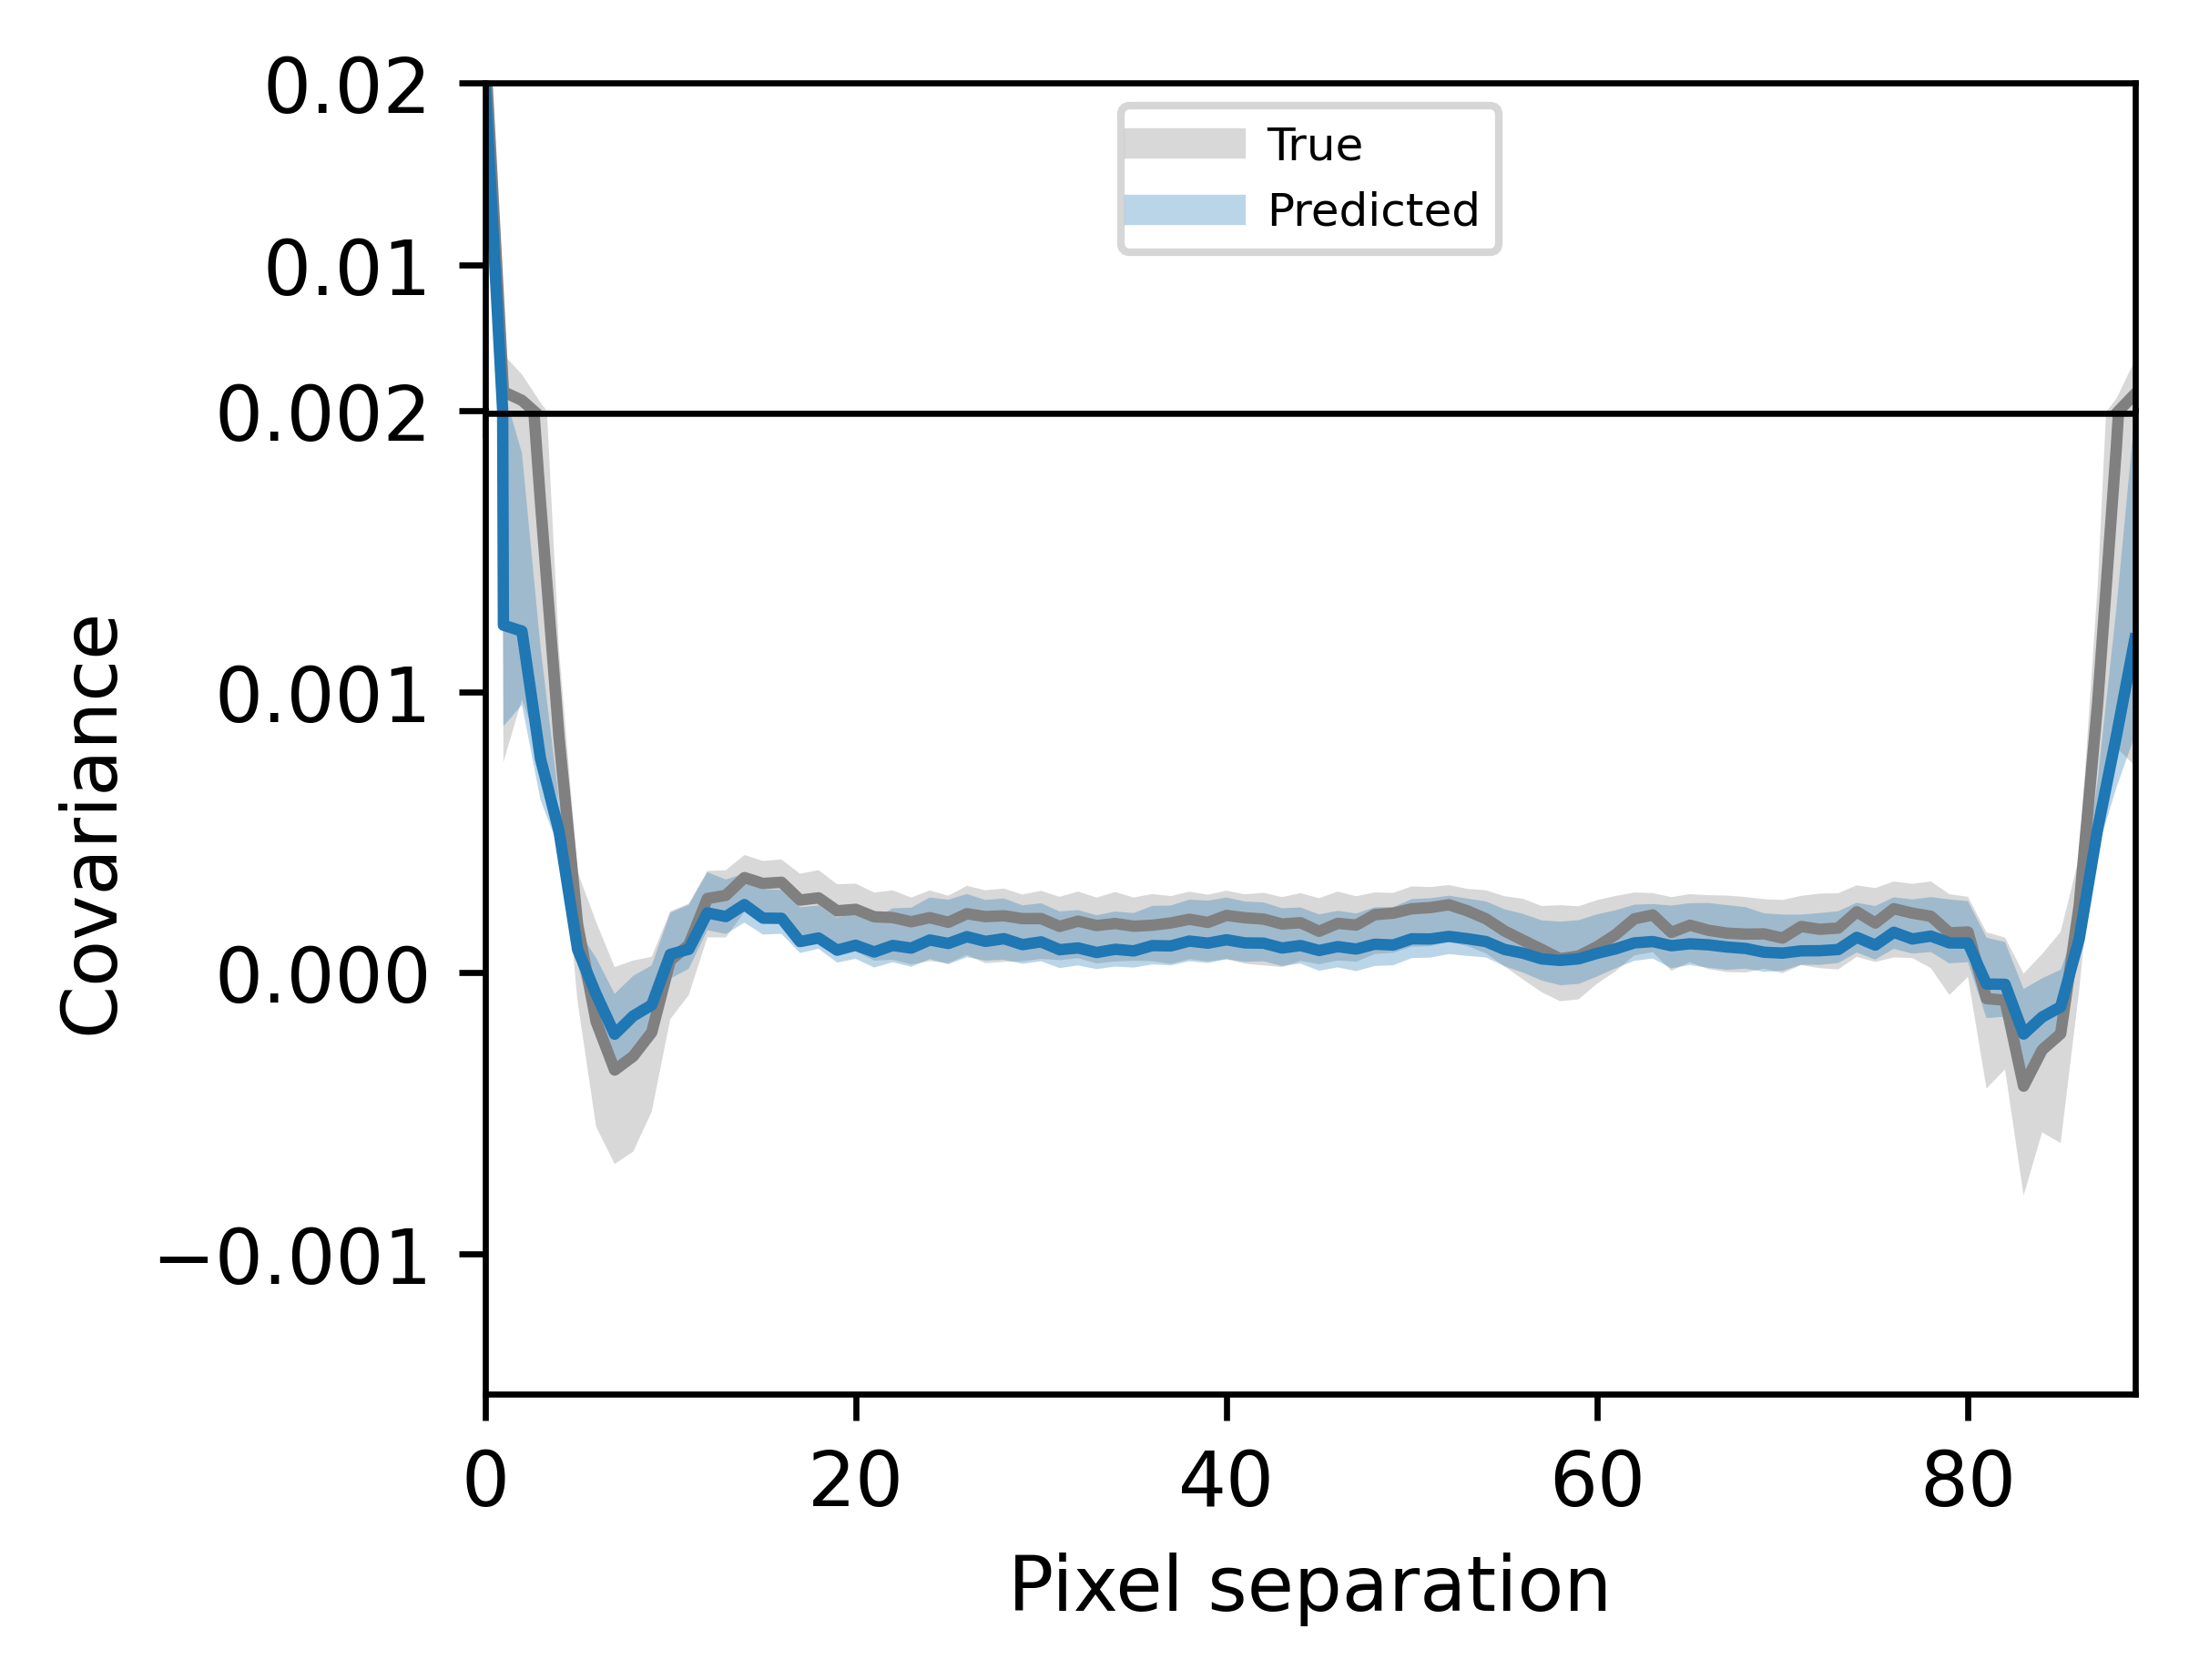

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec


def plot_cov_band(ax, x, covs, color, alpha=0.3, lw=1.5, label=None, ls='-'):
    """Plot mean ± std covariance band."""
    mean = covs.mean(axis=0)
    std  = covs.std(axis=0)

    ax.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=alpha,
        zorder=0,
        lw=0,
        label=label
    )
    ax.plot(x, mean, color=color, lw=lw, ls=ls, zorder=1)


def plot_cov_band_dist(ax, x, covs, color, alpha=0.3, lw=1.5, label=None, ls='-'):
    """Plot mean ± std covariance band."""
    median = np.median(covs, axis=0)

    lo = np.percentile(covs, 16, axis=0)
    hi = np.percentile(covs, 84, axis=0)


    ax.fill_between(
        x,
        lo,
        hi,
        color=color,
        alpha=alpha,
        zorder=0,
        lw=0,
        label=label
    )
    ax.plot(x, median, color=color, lw=lw, ls=ls, zorder=1)



# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
_x = np.arange(true_test_cov_vs_r.shape[1])

fig = plt.figure(dpi=600, figsize=(4, 3))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.0)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

axis_break = 0.002


# ------------------------------------------------------------
# Unregularized covariances
# ------------------------------------------------------------
for ax in (ax_top, ax_bot):
    plot_cov_band_dist(
        ax,
        _x,
        true_test_cov_vs_r,
        color='gray',
        label='true'
    )

# # Global mean (unregularized)
# for ax in (ax_top, ax_bot):
#     ax.plot(
#         _x,
#         true_test_cov_vs_r.mean(axis=0),
#         color='k',
#         ls='--',
#         lw=1,
#         label='Global cov'
#     )


# ------------------------------------------------------------
# Regularized covariances
# ------------------------------------------------------------
for ax in (ax_top, ax_bot):
    plot_cov_band_dist(
        ax,
        _x,
        pred_test_cov_vs_r,
        color='C0',
        label=f'predicted'
    )


# ------------------------------------------------------------
# Axis limits and split formatting
# ------------------------------------------------------------
ax_top.set_ylim(axis_break, 0.02)
ax_bot.set_ylim(-0.0015, axis_break)

ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(labelbottom=False)

ax_bot.set_xlim(_x[0], _x[-1])
ax_bot.set_xlabel('Pixel separation')
fig.text(0.045, 0.5, 'Covariance', ha='center', va='center', rotation='vertical')

# Optional break indicator
ax_bot.plot([_x[0], _x[-1]], [axis_break, axis_break],
            color='k', lw=1.5)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
legend_handles = [
    # Line2D([0], [0], color='k', lw=1, ls='--', label='Global (mean) cov'),
    Line2D([0], [0], color='gray', lw=4, alpha=0.3,
           label='True'),
    Line2D([0], [0], color='C0', lw=4, alpha=0.3,
           label=f'Predicted'),
]

ax_top.legend(
    handles=legend_handles,
    loc='upper center',
    fontsize=6,
    frameon=True
)

plt.subplots_adjust(
    left=0.225,
    right=0.98,
    bottom=0.15,
    top=0.95,
    hspace=0.0,
)

plt.show()


In [112]:
Npix = B.shape[0]
assert pixel_sep_rav.shape[0] == Npix * Npix

# spot-check a handful of random (i,j)
import numpy as np
idx = np.random.default_rng(0).integers(0, Npix, size=(10,2))
for i,j in idx:
    p = i*Npix + j
    # pixel_sep_rav[p] should equal separation(i,j)
    # compute sep(i,j) your "slow" trusted way here and compare


NameError: name 'B' is not defined